## IMPORTACIÓN DE LIBRERÍAS

In [83]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

# Modelado
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Métricas
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


In [84]:
#Funcion para mostrar df sin limite de filas o cols

def MostrarSinLimite(o):
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', 1000)
    display(o)
    pd.reset_option('display.max_columns')
    pd.reset_option('display.max_rows')
    pd.reset_option('display.width')

##  CARGA Y REVISIÓN DE ARCHIVOS

In [85]:
def load_parquet_folder(folder_path):
    """Carga todos los archivos parquet de una carpeta y los concatena"""
    parquet_files = list(Path(folder_path).rglob("*.parq"))
    
    if not parquet_files:
        print(f"No se encontraron archivos en {folder_path}")
        return None
    
    dfs = [pd.read_parquet(f, engine='pyarrow') for f in parquet_files]
    df_final = pd.concat(dfs, ignore_index=True)
    
    print(f"Cargado: {df_final.shape[0]:,} filas x {df_final.shape[1]} columnas")
    return df_final

In [86]:
# Rutas de datos
PATH_CLIENTES = "cbros_ct_datos_cliente_masked/cbros_ct_datos_cliente_masked"
PATH_GESTIONES = "cbros_ct_gestiones_procesadas_masked/cbros_ct_gestiones_procesadas_masked"
PATH_MEJOR_CANAL = "cbros_ct_mejor_canal_masked/cbros_ct_mejor_canal_masked"

print("Cargando datasets...\n")

# Cargar datasets
df_gp = load_parquet_folder(PATH_GESTIONES)
df_mc = load_parquet_folder(PATH_MEJOR_CANAL)
df_dc = load_parquet_folder(PATH_CLIENTES)


Cargando datasets...

Cargado: 528,546 filas x 8 columnas
Cargado: 201,979 filas x 3 columnas
Cargado: 13,556,034 filas x 42 columnas


In [87]:
# Revisión rápida de cada dataset


print("\n1. Gestiones Procesadas:")
print(f"   - Shape: {df_gp.shape}")
print(f"   - Clientes únicos: {df_gp['id_masked'].nunique():,}")
print(f"   - Columnas: {df_gp.columns.tolist()[:8]}...")

print("\n2. Mejor Canal:")
print(f"   - Shape: {df_mc.shape}")
print(f"   - Clientes únicos: {df_mc['id_masked'].nunique():,}")
print(f"   - Canales: {df_mc['mejor_canal_contacto'].unique()[:5]}...")

print("\n3. Datos Cliente:")
print(f"   - Shape: {df_dc.shape}")
print(f"   - Clientes únicos: {df_dc['id_masked'].nunique():,}")


1. Gestiones Procesadas:
   - Shape: (528546, 8)
   - Clientes únicos: 106,419
   - Columnas: ['id_masked', 'timestamp_gestion', 'accion', 'resultado', 'contacto_cliente', 'canal', 'tipo_terminal', 'tipo_telefono']...

2. Mejor Canal:
   - Shape: (201979, 3)
   - Clientes únicos: 106,419
   - Canales: [b'no_preferencia' b'linea_movil' b'whatsapp']...

3. Datos Cliente:
   - Shape: (13556034, 42)
   - Clientes únicos: 3,407,613


In [88]:
# Filtrar solo el último mes
ultimo_mes = df_mc["fin_mes"].max()
df_mc_ultimo_mes = df_mc[df_mc["fin_mes"] == ultimo_mes].copy()

print(f"Último mes disponible: {ultimo_mes}")
print(f"Registros del último mes: {len(df_mc_ultimo_mes):,}\n")

Último mes disponible: 2024-12-31 00:00:00
Registros del último mes: 53,453



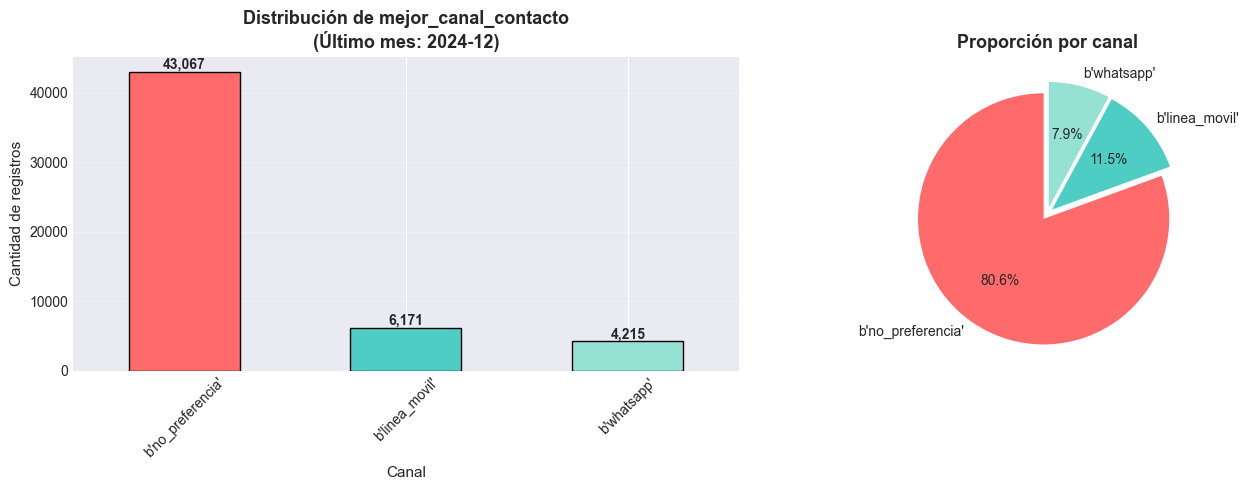

In [89]:


# Visualización de la distribución de mejor_canal_contacto (último mes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
conteo = df_mc_ultimo_mes["mejor_canal_contacto"].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
conteo.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title(f'Distribución de mejor_canal_contacto\n(Último mes: {ultimo_mes.strftime("%Y-%m")})', 
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Canal', fontsize=11)
axes[0].set_ylabel('Cantidad de registros', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(conteo):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
conteo.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=colors, 
            startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Proporción por canal', fontweight='bold', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [90]:
# Distribución por mes
dist_por_mes = df_mc.groupby(['fin_mes', 'mejor_canal_contacto']).size().unstack(fill_value=0)
dist_por_mes_pct = dist_por_mes.div(dist_por_mes.sum(axis=1), axis=0) * 100
print("\nDistribución mensual (%):")
print(dist_por_mes_pct.round(1))


Distribución mensual (%):
mejor_canal_contacto  b'linea_movil'  b'no_preferencia'  b'whatsapp'
fin_mes                                                             
2024-09-30                      10.8               81.8          7.4
2024-10-31                      12.4               80.5          7.1
2024-11-30                      12.8               79.5          7.7
2024-12-31                      11.5               80.6          7.9


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

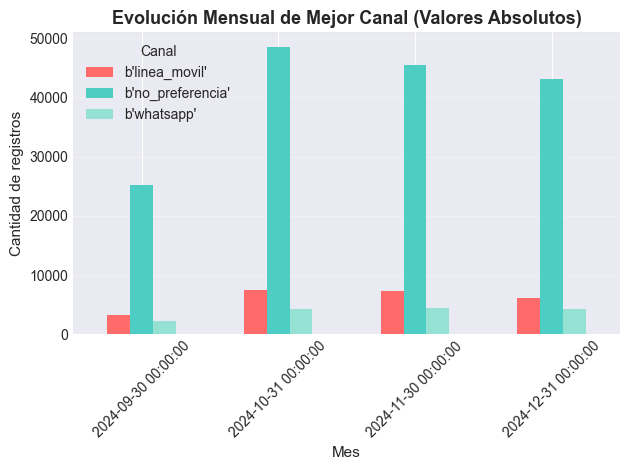

In [91]:
# Visualización mejor canal 
plt.figure(figsize=(12, 6))

# Gráfico: barras
dist_por_mes.plot(kind='bar', stacked=False, color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
plt.title('Evolución Mensual de Mejor Canal (Valores Absolutos)', fontweight='bold', fontsize=13)
plt.xlabel('Mes', fontsize=11)
plt.ylabel('Cantidad de registros', fontsize=11)
plt.legend(title='Canal')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



In [92]:
# Generando features de gestiones procesadas
df_gp["timestamp_gestion"] = pd.to_datetime(df_gp["timestamp_gestion"])
df_gp["fin_mes"] = df_gp["timestamp_gestion"].dt.normalize() + pd.offsets.MonthEnd(0)
df_gp

,id_masked,timestamp_gestion,accion,resultado,contacto_cliente,canal,tipo_terminal,tipo_telefono,fin_mes
0,-2.307531e+18,2024-10-10 01:07:26.301,b'0007 Llamada a Celular Deudor',b'0002 Tel\xc3\xa9fono no contesta',0,b'LINEA TELEFONICA',b'Fijo',b'LABORAL',2024-10-31
1,-5.193638e+18,2024-10-28 00:49:40.301,b'0004 Llamada a Oficina Deudor',b'0006 Tercero proporciona Datos',0,b'LINEA TELEFONICA',b'Fijo',b'RESIDENCIAL',2024-10-31
2,-5.193638e+18,2024-10-23 01:18:02.301,b'0004 Llamada a Oficina Deudor',b'0006 Tercero proporciona Datos',0,b'LINEA TELEFONICA',b'Fijo',b'RESIDENCIAL',2024-10-31
3,-5.193638e+18,2024-10-24 01:35:36.701,b'0004 Llamada a Oficina Deudor',b'0006 Tercero proporciona Datos',0,b'LINEA TELEFONICA',b'Fijo',b'RESIDENCIAL',2024-10-31
4,-5.193638e+18,2024-10-31 00:53:55.101,b'0004 Llamada a Oficina Deudor',b'0006 Tercero proporciona Datos',0,b'LINEA TELEFONICA',b'Fijo',b'RESIDENCIAL',2024-10-31
...,...,...,...,...,...,...,...,...,...
528541,4.905818e+18,2024-10-24 01:47:46.301,b'0007 Llamada a Celular Deudor',b'0002 Tel\xc3\xa9fono no contesta',0,b'LINEA TELEFONICA',b'Movil',None,2024-10-31
528542,-5.769761e+18,2024-11-05 01:40:04.401,b'0007 Llamada a Celular Deudor',b'0002 Tel\xc3\xa9fono no contesta',0,b'LINEA TELEFONICA',b'Movil',None,2024-11-30
528543,-5.769761e+18,2024-09-27 01:21:08.401,b'0007 Llamada a Celular Deudor',b'0002 Tel\xc3\xa9fono no contesta',0,b'LINEA TELEFONICA',b'Movil',None,2024-09-30
528544,-5.769761e+18,2024-10-08 01:28:37.801,b'0007 Llamada a Celular Deudor',b'0002 Tel\xc3\xa9fono no contesta',0,b'LINEA TELEFONICA',b'Movil',None,2024-10-31


In [93]:
# Agregados por cliente y mes
agg_gp = df_gp.groupby(["id_masked", "fin_mes"]).agg(
    contactos_exitosos=("contacto_cliente", "sum"),
    intentos_totales=("contacto_cliente", "count"),
    tasa_contacto=("contacto_cliente", "mean"),
    canal_mas_usado=("canal", lambda x: x.mode()[0] if not x.mode().empty else "desconocido")
).reset_index()
agg_gp

,id_masked,fin_mes,contactos_exitosos,intentos_totales,tasa_contacto,canal_mas_usado
0,-9.223301e+18,2024-12-31,0,1,0.000000,b'LINEA TELEFONICA'
1,-9.223003e+18,2024-11-30,0,1,0.000000,b'LINEA TELEFONICA'
2,-9.223003e+18,2024-12-31,0,1,0.000000,b'LINEA TELEFONICA'
3,-9.222997e+18,2024-10-31,0,1,0.000000,b'LINEA TELEFONICA'
4,-9.222997e+18,2024-11-30,0,1,0.000000,b'LINEA TELEFONICA'
...,...,...,...,...,...,...
201973,9.222824e+18,2024-09-30,1,1,1.000000,b'WHATSAPP'
201974,9.222977e+18,2024-10-31,5,6,0.833333,b'LINEA TELEFONICA'
201975,9.222977e+18,2024-12-31,0,1,0.000000,b'LINEA TELEFONICA'
201976,9.223283e+18,2024-11-30,0,1,0.000000,b'LINEA TELEFONICA'


In [94]:
# Filtrar solo el último mes
ultimo_mes =df_gp["fin_mes"].max()
df_gp_ultimo_mes = df_gp[df_gp["fin_mes"] == ultimo_mes].copy()

print(f"Último mes disponible: {ultimo_mes}")
print(f"Registros del último mes: {len(df_gp_ultimo_mes):,}\n")

Último mes disponible: 2024-12-31 00:00:00
Registros del último mes: 140,969



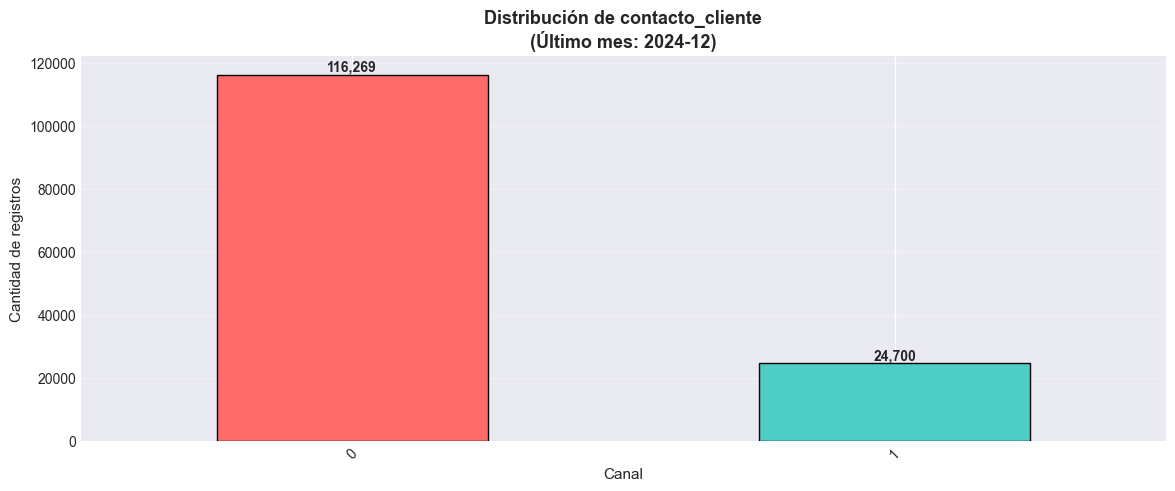

In [95]:
# Visualización de la distribución de mejor_canal_contacto (último mes)
plt.figure( figsize=(14, 5))

# Gráfico de barras
conteo = df_gp_ultimo_mes["contacto_cliente"].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
conteo.plot(kind='bar', color=colors, edgecolor='black')
plt.title(f'Distribución de contacto_cliente\n(Último mes: {ultimo_mes.strftime("%Y-%m")})', fontweight='bold', fontsize=13)
plt.xlabel('Canal', fontsize=11)
plt.ylabel('Cantidad de registros', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(conteo):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

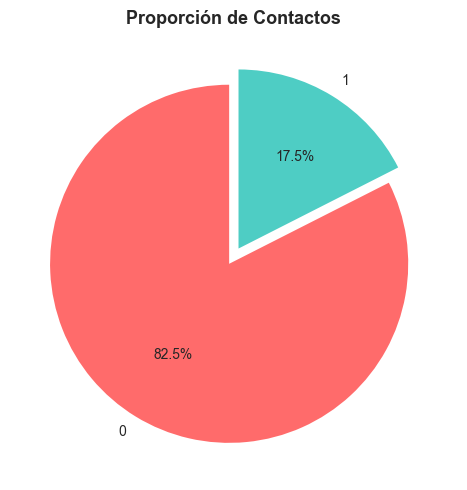

In [96]:
# Gráfico de pastel
fig, axes = plt.subplots( figsize=(14, 5))
# Crear explode dinámicamente según la cantidad de categorías
explode_values = tuple([0.05] * len(conteo))
conteo.plot(kind='pie', ax=axes, autopct='%1.1f%%', colors=colors[:len(conteo)],  startangle=90, explode=explode_values)
axes.set_title('Proporción de Contactos', fontweight='bold', fontsize=13)
axes.set_ylabel('')

plt.tight_layout()
plt.show()

In [97]:
# Análisis por canal: intentos y contactos exitosos
analisis_canal = df_gp_ultimo_mes.groupby('canal').agg(
    intentos_totales=('contacto_cliente', 'count'),
    contactos_exitosos=('contacto_cliente', 'sum'),
).reset_index()
# Calcular tasa de éxito
analisis_canal['tasa_exito'] = (analisis_canal['contactos_exitosos'] / analisis_canal['intentos_totales'] * 100).round(2)

# Ordenar por intentos totales
analisis_canal = analisis_canal.sort_values('intentos_totales', ascending=False)

print("\nEstadísticas por canal:")
print(analisis_canal.to_string(index=False))


Estadísticas por canal:
              canal  intentos_totales  contactos_exitosos  tasa_exito
b'LINEA TELEFONICA'             97692               11214       11.48
        b'WHATSAPP'             43277               13486       31.16


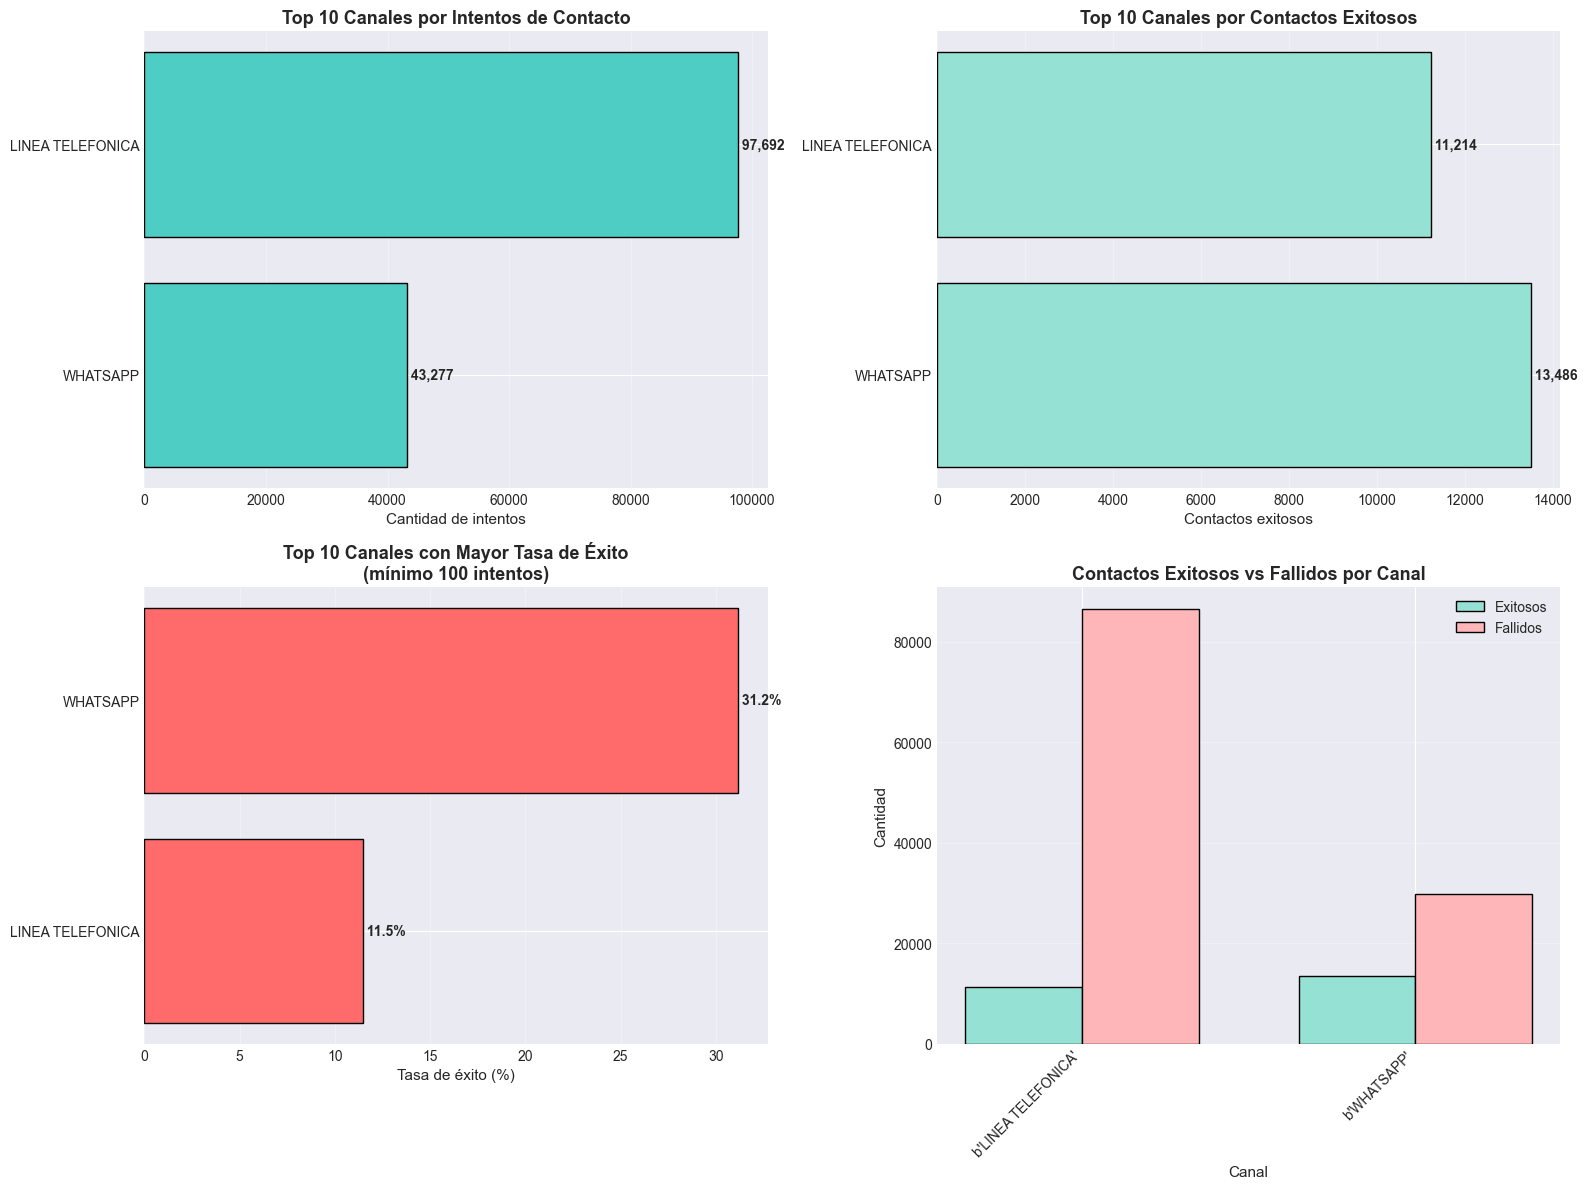

In [98]:

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Intentos totales por canal
top_canales = analisis_canal.head(10)
axes[0, 0].barh(top_canales['canal'], top_canales['intentos_totales'], color='#4ECDC4', edgecolor='black')
axes[0, 0].set_xlabel('Cantidad de intentos', fontsize=11)
axes[0, 0].set_title('Top 10 Canales por Intentos de Contacto', fontweight='bold', fontsize=13)
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)
for i, (idx, row) in enumerate(top_canales.iterrows()):
    axes[0, 0].text(row['intentos_totales'], i, f" {row['intentos_totales']:,}", 
                    va='center', fontweight='bold')

# Gráfico 2: Contactos exitosos por canal
axes[0, 1].barh(top_canales['canal'], top_canales['contactos_exitosos'], color='#95E1D3', edgecolor='black')
axes[0, 1].set_xlabel('Contactos exitosos', fontsize=11)
axes[0, 1].set_title('Top 10 Canales por Contactos Exitosos', fontweight='bold', fontsize=13)
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)
for i, (idx, row) in enumerate(top_canales.iterrows()):
    axes[0, 1].text(row['contactos_exitosos'], i, f" {row['contactos_exitosos']:,}", 
                    va='center', fontweight='bold')

# Gráfico 3: Tasa de éxito por canal (solo canales con >100 intentos)
canales_significativos = analisis_canal[analisis_canal['intentos_totales'] >= 100].sort_values('tasa_exito', ascending=False).head(10)
axes[1, 0].barh(canales_significativos['canal'], canales_significativos['tasa_exito'], color='#FF6B6B', edgecolor='black')
axes[1, 0].set_xlabel('Tasa de éxito (%)', fontsize=11)
axes[1, 0].set_title('Top 10 Canales con Mayor Tasa de Éxito\n(mínimo 100 intentos)', fontweight='bold', fontsize=13)
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)
for i, (idx, row) in enumerate(canales_significativos.iterrows()):
    axes[1, 0].text(row['tasa_exito'], i, f" {row['tasa_exito']:.1f}%", 
                    va='center', fontweight='bold')

# Gráfico 4: Comparativa exitosos vs fallidos para top 5 canales
top5 = analisis_canal.head(5)
x = np.arange(len(top5))
width = 0.35

exitosos = top5['contactos_exitosos'].values
fallidos = (top5['intentos_totales'] - top5['contactos_exitosos']).values

axes[1, 1].bar(x - width/2, exitosos, width, label='Exitosos', color='#95E1D3', edgecolor='black')
axes[1, 1].bar(x + width/2, fallidos, width, label='Fallidos', color='#FFB6B9', edgecolor='black')
axes[1, 1].set_xlabel('Canal', fontsize=11)
axes[1, 1].set_ylabel('Cantidad', fontsize=11)
axes[1, 1].set_title('Contactos Exitosos vs Fallidos por Canal', fontweight='bold', fontsize=13)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(top5['canal'].values, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()




##  PREPARACIÓN DEL DATAFRAME PRINCIPAL

In [99]:
# Convertir fechas
df_gp["timestamp_gestion"] = pd.to_datetime(df_gp["timestamp_gestion"])
df_gp["fecha_mes"] = df_gp["timestamp_gestion"].dt.to_period('M').dt.to_timestamp()

df_mc["fin_mes"] = pd.to_datetime(df_mc["fin_mes"])
df_dc["fin_mes"] = pd.to_datetime(df_dc["fecha_proceso"])

# Contar registros por mes en df_gp
print("\n Distribución de gestiones por mes:")
print(df_gp['fecha_mes'].value_counts().sort_index())

# Definir periodos según disponibilidad de datos
meses_disponibles = sorted(df_gp['fecha_mes'].unique())
print(f"\nTotal de meses con gestiones: {len(meses_disponibles)}")

# Convertir numpy.datetime64 a pd.Timestamp para poder usar strftime
meses_disponibles = [pd.Timestamp(m) for m in meses_disponibles]
print(f"Meses disponibles: {[m.strftime('%Y-%m') for m in meses_disponibles]}")

# Definir períodos temporales basados en datos disponibles
if len(meses_disponibles) >= 4:
    # Usar los últimos 4 meses: 3 históricos + 1 target (OOT se agregará después)
    meses_historico = meses_disponibles[:-1]  # Todos menos el último
    mes_target = meses_disponibles[-1]         # Último mes
    mes_oot = None  # Se definirá cuando tengas datos de enero 2025        
else:  
    raise ValueError("No hay meses de datos")




 Distribución de gestiones por mes:
2024-09-01     67726
2024-10-01    164141
2024-11-01    155710
2024-12-01    140969
Name: fecha_mes, dtype: int64

Total de meses con gestiones: 4
Meses disponibles: ['2024-09', '2024-10', '2024-11', '2024-12']


In [100]:
# Construir Features Históricas (hasta t-1)

# Filtrar solo periodo histórico
df_historico = df_gp[df_gp['fecha_mes'].isin(meses_historico)].copy()
print(f"\n Registros en periodo histórico: {len(df_historico):,}")
print(f"   Clientes únicos: {df_historico['id_masked'].nunique():,}")

# Filtrar solo canales relevantes: LINEA TELEFONICA y WHATSAPP
# NOTA: Los canales están en bytes (b'...') en los datos
canales_interes = [b'LINEA TELEFONICA', b'WHATSAPP']
df_historico_canales = df_historico[df_historico['canal'].isin(canales_interes)].copy()

print(f"\n Registros de LINEA TELEFONICA y WHATSAPP: {len(df_historico_canales):,}")
print(f"   Distribución por canal:")
print(df_historico_canales['canal'].value_counts())

# Normalizar nombres de canales para facilitar el pivot
# Convertir bytes a string y normalizar nombres
df_historico_canales['canal'] = df_historico_canales['canal'].apply(lambda x: 'linea_movil' if b'LINEA' in x else 'whatsapp')

print(f"\n Canales normalizados:")
print(df_historico_canales['canal'].value_counts())


 Registros en periodo histórico: 387,577
   Clientes únicos: 94,453

 Registros de LINEA TELEFONICA y WHATSAPP: 387,577
   Distribución por canal:
b'LINEA TELEFONICA'    281940
b'WHATSAPP'            105637
Name: canal, dtype: int64

 Canales normalizados:
linea_movil    281940
whatsapp       105637
Name: canal, dtype: int64


In [101]:
# Agregaciones por cliente y canal (histórico)
agg_hist = df_historico_canales.groupby(["id_masked", "canal"]).agg(
    intentos_hist=("contacto_cliente", "count"),  # Total de intentos
    exitos_hist=("contacto_cliente", "sum")        # Total de contactos exitosos
).reset_index()

print(f"\n Agregaciones históricas creadas: {len(agg_hist):,} registros")


 Agregaciones históricas creadas: 113,610 registros


In [102]:
# Calcular RPC histórico (Rate Per Contact)
agg_hist["rpc_hist"] = (
    agg_hist["exitos_hist"] / 
    agg_hist["intentos_hist"].replace(0, np.nan)
)

# Mostrar muestra
print("\nMuestra de agregaciones históricas:")
print(agg_hist.head(10))


Muestra de agregaciones históricas:
      id_masked        canal  intentos_hist  exitos_hist  rpc_hist
0 -9.223003e+18  linea_movil              1            0  0.000000
1 -9.222997e+18  linea_movil              2            0  0.000000
2 -9.222469e+18  linea_movil              1            0  0.000000
3 -9.222469e+18     whatsapp              8            2  0.250000
4 -9.221978e+18  linea_movil              2            0  0.000000
5 -9.221862e+18  linea_movil              1            0  0.000000
6 -9.221561e+18  linea_movil              7            1  0.142857
7 -9.221482e+18  linea_movil              5            0  0.000000
8 -9.221474e+18  linea_movil              2            0  0.000000
9 -9.221259e+18  linea_movil             10            0  0.000000


In [103]:
# Pivotear para tener columnas por canal
features = agg_hist.pivot(
    index="id_masked",
    columns="canal",
    values=["intentos_hist", "exitos_hist", "rpc_hist"]
)

# Aplanar columnas multi-nivel
features.columns = ['_'.join(col).strip() for col in features.columns.values]
features = features.reset_index()

# Rellenar NaN con 0 (clientes sin gestiones en ese canal)
features = features.fillna(0)

print(f"\n Features pivotadas: {features.shape}")
print(f"   Columnas: {features.columns.tolist()}")
print(f"\nPrimeras filas:")
MostrarSinLimite(features.head())


 Features pivotadas: (94453, 7)
   Columnas: ['id_masked', 'intentos_hist_linea_movil', 'intentos_hist_whatsapp', 'exitos_hist_linea_movil', 'exitos_hist_whatsapp', 'rpc_hist_linea_movil', 'rpc_hist_whatsapp']

Primeras filas:


,id_masked,intentos_hist_linea_movil,intentos_hist_whatsapp,exitos_hist_linea_movil,exitos_hist_whatsapp,rpc_hist_linea_movil,rpc_hist_whatsapp
0,-9.223003e+18,1.0,0.0,0.0,0.0,0.0,0.00
1,-9.222997e+18,2.0,0.0,0.0,0.0,0.0,0.00
2,-9.222469e+18,1.0,8.0,0.0,2.0,0.0,0.25
3,-9.221978e+18,2.0,0.0,0.0,0.0,0.0,0.00
4,-9.221862e+18,1.0,0.0,0.0,0.0,0.0,0.00


In [104]:
# Construir Target (comportamiento en mes t)

# Filtrar solo mes target
df_target_mes = df_gp[df_gp['fecha_mes'] == mes_target].copy()
print(f"\n Registros en mes target ({mes_target.strftime('%Y-%m')}): {len(df_target_mes):,}")
print(f"   Clientes únicos: {df_target_mes['id_masked'].nunique():,}")

# Filtrar solo canales relevantes
df_target_canales = df_target_mes[df_target_mes['canal'].isin(canales_interes)].copy()

print(f"\nRegistros de LINEA TELEFONICA y WHATSAPP en mes target: {len(df_target_canales):,}")
print(f"   Distribución por canal:")
print(df_target_canales['canal'].value_counts())


 Registros en mes target (2024-12): 140,969
   Clientes únicos: 53,453

Registros de LINEA TELEFONICA y WHATSAPP en mes target: 140,969
   Distribución por canal:
b'LINEA TELEFONICA'    97692
b'WHATSAPP'            43277
Name: canal, dtype: int64


In [105]:
# Normalizar nombres de canales (igual que en histórico)
df_target_canales['canal'] = df_target_canales['canal'].apply(
    lambda x: 'linea_movil' if b'LINEA' in x else 'whatsapp'
)
print(f"\nCanales normalizados:")
print(df_target_canales['canal'].value_counts())

# Agregaciones por cliente y canal (mes target)
target_agg = df_target_canales.groupby(["id_masked", "canal"]).agg(
    intentos_t=("contacto_cliente", "count"),
    exitos_t=("contacto_cliente", "sum")
).reset_index()
print(f"\nAgregaciones de target creadas: {len(target_agg):,} registros")

# Calcular RPC en mes target
target_agg["rpc_t"] = (
    target_agg["exitos_t"] / 
    target_agg["intentos_t"].replace(0, np.nan)
)
# Pivotear
target = target_agg.pivot(
    index="id_masked",
    columns="canal",
    values=["intentos_t", "exitos_t", "rpc_t"]
)

# Aplanar columnas
target.columns = ['_'.join(col).strip() for col in target.columns.values]
target = target.reset_index()

# Rellenar NaN con 0
target = target.fillna(0)

print(f"\nTarget pivotado: {target.shape}")
print(f"Columnas: {target.columns.tolist()}")
print(f"\nPrimeras filas:")
MostrarSinLimite(target.head())


Canales normalizados:
linea_movil    97692
whatsapp       43277
Name: canal, dtype: int64

Agregaciones de target creadas: 63,358 registros

Target pivotado: (53453, 7)
Columnas: ['id_masked', 'intentos_t_linea_movil', 'intentos_t_whatsapp', 'exitos_t_linea_movil', 'exitos_t_whatsapp', 'rpc_t_linea_movil', 'rpc_t_whatsapp']

Primeras filas:


,id_masked,intentos_t_linea_movil,intentos_t_whatsapp,exitos_t_linea_movil,exitos_t_whatsapp,rpc_t_linea_movil,rpc_t_whatsapp
0,-9.223301e+18,1.0,0.0,0.0,0.0,0.0,0.0
1,-9.223003e+18,1.0,0.0,0.0,0.0,0.0,0.0
2,-9.222764e+18,5.0,0.0,1.0,0.0,0.2,0.0
3,-9.221978e+18,1.0,0.0,0.0,0.0,0.0,0.0
4,-9.221561e+18,1.0,0.0,1.0,0.0,1.0,0.0


In [106]:
# Crear variable respuesta basada en RPC comparativo

# Merge features históricas con target
df_modelo = features.merge(target, on="id_masked", how="inner")

print(f"\n Dataset combinado: {df_modelo.shape}")
print(f"   Clientes: {len(df_modelo):,}")

# Verificar que tenemos las columnas de RPC
print(f"\n Columnas disponibles:")
print([col for col in df_modelo.columns if 'rpc' in col.lower()])

# Crear variable respuesta: 1 si RPC linea_movil > RPC whatsapp en mes t
# Esto significa que linea_movil funcionó MEJOR que whatsapp para ese cliente
df_modelo["var_resp"] = (
    df_modelo["rpc_t_linea_movil"] > df_modelo["rpc_t_whatsapp"]
).astype(int)

print(f"\n Distribución:")
print(df_modelo['var_resp'].value_counts())
print(f"\nProporción:")
print(df_modelo['var_resp'].value_counts(normalize=True))


 Dataset combinado: (41487, 13)
   Clientes: 41,487

 Columnas disponibles:
['rpc_hist_linea_movil', 'rpc_hist_whatsapp', 'rpc_t_linea_movil', 'rpc_t_whatsapp']

 Distribución:
0    36947
1     4540
Name: var_resp, dtype: int64

Proporción:
0    0.890568
1    0.109432
Name: var_resp, dtype: float64


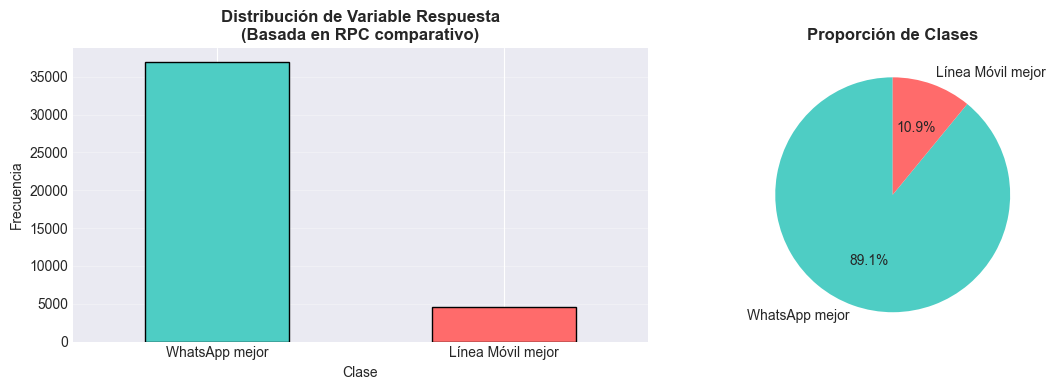

In [107]:
# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
df_modelo['var_resp'].value_counts().plot(kind='bar', ax=axes[0], color=['#4ECDC4', '#FF6B6B'], edgecolor='black')
axes[0].set_title('Distribución de Variable Respuesta\n(Basada en RPC comparativo)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Clase')
axes[0].set_xticklabels(['WhatsApp mejor', 'Línea Móvil mejor'], rotation=0)
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

# Porcentaje
df_modelo['var_resp'].value_counts(normalize=True).plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'],
    labels=['WhatsApp mejor', 'Línea Móvil mejor'], startangle=90
)
axes[1].set_title('Proporción de Clases', fontweight='bold', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


In [108]:
df_dc["fin_mes"] = pd.to_datetime(df_dc["fecha_proceso"])
df_dc = df_dc.sort_values(["id_masked", "fin_mes"]).drop_duplicates(["id_masked", "fin_mes"], keep="last")
df_dc

,id_masked,fecha_mes,fecha_proceso,max_fecha_proceso,codigo_tipo_cliente,area_financiera,nombre_area_financiera,genero,estado_civil,es_hombre,...,activo_digital_1m,activo_digital_3m,activo_digital_omni_1m,activo_digital_omni_3m,activo_digital_bm_1m,activo_digital_bm_3m,estado_cuenta,tiene_omni,tiene_ebancaemp,fin_mes
286221,-9223370889828977834,202409,2024-09-30,2025-04-30,b'I',1524.0,b'SEGMENTO ASALARIADO',b'M',b'SOLTERO',1,...,0,1,0,1,0,0,b'DISPONIBLE',1,0,2024-09-30
286220,-9223370889828977834,202410,2024-10-31,2025-04-30,b'I',1524.0,b'SEGMENTO ASALARIADO',b'M',b'SOLTERO',1,...,0,1,0,1,0,0,b'DISPONIBLE',1,0,2024-10-31
286219,-9223370889828977834,202411,2024-11-30,2025-04-30,b'I',1524.0,b'SEGMENTO ASALARIADO',b'M',b'SOLTERO',1,...,0,0,0,0,0,0,b'DISPONIBLE',1,0,2024-11-30
286218,-9223370889828977834,202412,2024-12-31,2025-04-30,b'I',1524.0,b'SEGMENTO ASALARIADO',b'M',b'SOLTERO',1,...,0,0,0,0,0,0,b'DISPONIBLE',1,0,2024-12-31
5519228,-9223370588714861151,202409,2024-09-30,2025-04-30,b'I',9999.0,b'CLIENTES NO ASIGN.',b'F',b'SOLTERO',0,...,0,0,0,0,0,0,b'DISPONIBLE',1,0,2024-09-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11145604,9223358924255936387,202412,2024-12-31,2025-04-30,b'I',1251.0,b'TRABAJADORES INDEPENDIENTES',b'M',b'SOLTERO',1,...,0,0,0,0,0,0,b'DESCONOCIDO',0,0,2024-12-31
8673307,9223368826213061618,202409,2024-09-30,2025-04-30,b'I',1200.0,b'SEGMENTO PERSONAL',b'F',b'SOLTERO',0,...,1,1,1,1,0,0,b'DISPONIBLE',1,0,2024-09-30
8673306,9223368826213061618,202410,2024-10-31,2025-04-30,b'I',1200.0,b'SEGMENTO PERSONAL',b'F',b'SOLTERO',0,...,1,1,1,1,0,0,b'DISPONIBLE',1,0,2024-10-31
8673305,9223368826213061618,202411,2024-11-30,2025-04-30,b'I',1200.0,b'SEGMENTO PERSONAL',b'F',b'SOLTERO',0,...,0,1,0,1,0,0,b'DISPONIBLE',1,0,2024-11-30


In [109]:
df_dc['fin_mes']

286221     2024-09-30
286220     2024-10-31
286219     2024-11-30
286218     2024-12-31
5519228    2024-09-30
              ...    
11145604   2024-12-31
8673307    2024-09-30
8673306    2024-10-31
8673305    2024-11-30
8673304    2024-12-31
Name: fin_mes, Length: 13556034, dtype: datetime64[ns]

In [110]:
# Agregar features demográficas (datos de cliente)

# Tomar datos de cliente del último mes histórico (para evitar leakage)
ultimo_mes_historico = meses_historico[-1]

# Comparar por año-mes (no por fecha exacta) porque df_dc['fin_mes'] tiene último día del mes
df_dc_hist = df_dc[
    (df_dc['fin_mes'].dt.year == ultimo_mes_historico.year) & 
    (df_dc['fin_mes'].dt.month == ultimo_mes_historico.month)
].copy()

print(f"\n Datos demográficos de {ultimo_mes_historico.strftime('%Y-%m')}")
print(f"   Clientes únicos: {df_dc_hist['id_masked'].nunique():,}")
print(f"   Columnas totales en df_dc: {len(df_dc_hist.columns)}")


 Datos demográficos de 2024-11
   Clientes únicos: 3,396,748
   Columnas totales en df_dc: 43


In [111]:
# Eliminar duplicados (último registro por cliente)
df_dc_hist = df_dc_hist.sort_values(['id_masked', 'fin_mes']).drop_duplicates(
    subset=['id_masked'], keep='last'
)

# Seleccionar TODAS las columnas demográficas (excluir solo identificadores y fechas)
cols_to_exclude = ['id_masked', 'fin_mes', 'fecha_proceso', 'index']
cols_demograficas = [col for col in df_dc_hist.columns 
                     if col not in cols_to_exclude]

print(f"\n Tipos de datos:")
tipos = df_dc_hist[cols_demograficas].dtypes.value_counts()
for tipo, count in tipos.items():
    print(f"   {tipo}: {count} columnas")


 Tipos de datos:
   int8: 15 columnas
   object: 13 columnas
   float64: 9 columnas
   int32: 2 columnas
   datetime64[ns]: 1 columnas


In [112]:
# Merge con dataset modelo
df_modelo = df_modelo.merge(
    df_dc_hist[['id_masked'] + cols_demograficas],
    on='id_masked',
    how='left'
)

In [113]:
MostrarSinLimite(df_modelo.head())

,id_masked,intentos_hist_linea_movil,intentos_hist_whatsapp,exitos_hist_linea_movil,exitos_hist_whatsapp,rpc_hist_linea_movil,rpc_hist_whatsapp,intentos_t_linea_movil,intentos_t_whatsapp,exitos_t_linea_movil,exitos_t_whatsapp,rpc_t_linea_movil,rpc_t_whatsapp,var_resp,fecha_mes,max_fecha_proceso,codigo_tipo_cliente,area_financiera,nombre_area_financiera,genero,estado_civil,es_hombre,casado,edad,antiguedad,cifcodocupaci,ocupacion,nsegmento,nsubsegmento,es_preferencial,es_asalariado,es_comercial,es_seg_personal,salario_total,tamano_comercial,clasificacion_fuente_ingreso,canal_mas_usado,en_lista_control,cifdeptdomici,cifciuddomici,flag_reestructurado,nivel_relacionamiento,status_cliente,entrada_efectivo_total,monto_remesas,activo_digital_1m,activo_digital_3m,activo_digital_omni_1m,activo_digital_omni_3m,activo_digital_bm_1m,activo_digital_bm_3m,estado_cuenta,tiene_omni,tiene_ebancaemp
0,-9.223003e+18,1.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-9.221978e+18,2.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-9.221561e+18,7.0,0.0,1.0,0.0,0.142857,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-9.221474e+18,2.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-9.221130e+18,4.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.0,0.0,1.0,0.0,0.5,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
# Convertir todas las columnas con bytes a string

cols_convertidas = []

# Revisar todas las columnas de tipo object
for col in df_modelo.select_dtypes(include=['object']).columns:
    # Verificar si la primera fila no nula es de tipo bytes
    first_valid = df_modelo[col].dropna().iloc[0] if len(df_modelo[col].dropna()) > 0 else None
    
    if isinstance(first_valid, bytes):
        # Convertir bytes a string
        df_modelo[col] = df_modelo[col].apply(
            lambda x: x.decode('utf-8') if isinstance(x, bytes) else x
        )
        cols_convertidas.append(col)

if len(cols_convertidas) > 0:
    print(f"\n Convertidas {len(cols_convertidas)} columnas de bytes a string:")
    for col in cols_convertidas:
        print(f"   - {col}")
else:
    print(f"\n No se encontraron columnas")

print(f"\n Tipos de datos actualizados:")
print(df_modelo.dtypes.value_counts())


 Convertidas 13 columnas de bytes a string:
   - codigo_tipo_cliente
   - nombre_area_financiera
   - genero
   - estado_civil
   - ocupacion
   - nsegmento
   - nsubsegmento
   - clasificacion_fuente_ingreso
   - canal_mas_usado
   - en_lista_control
   - nivel_relacionamiento
   - status_cliente
   - estado_cuenta

 Tipos de datos actualizados:
float64           39
object            13
int32              1
datetime64[ns]     1
dtype: int64


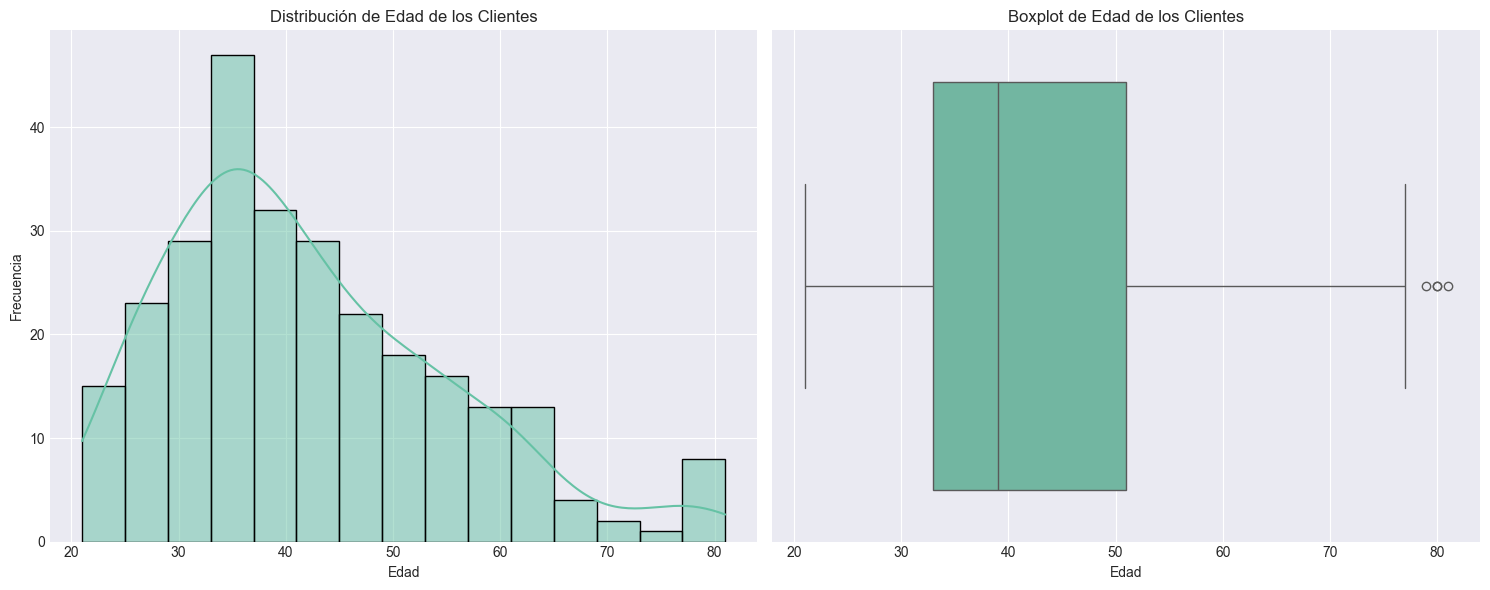

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma
sns.histplot(df_modelo['edad'], kde=True, bins=15, ax=axes[0])
axes[0].set_title('Distribución de Edad de los Clientes')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df_modelo['edad'], ax=axes[1])
axes[1].set_title('Boxplot de Edad de los Clientes')
axes[1].set_xlabel('Edad')

plt.tight_layout()
plt.show()

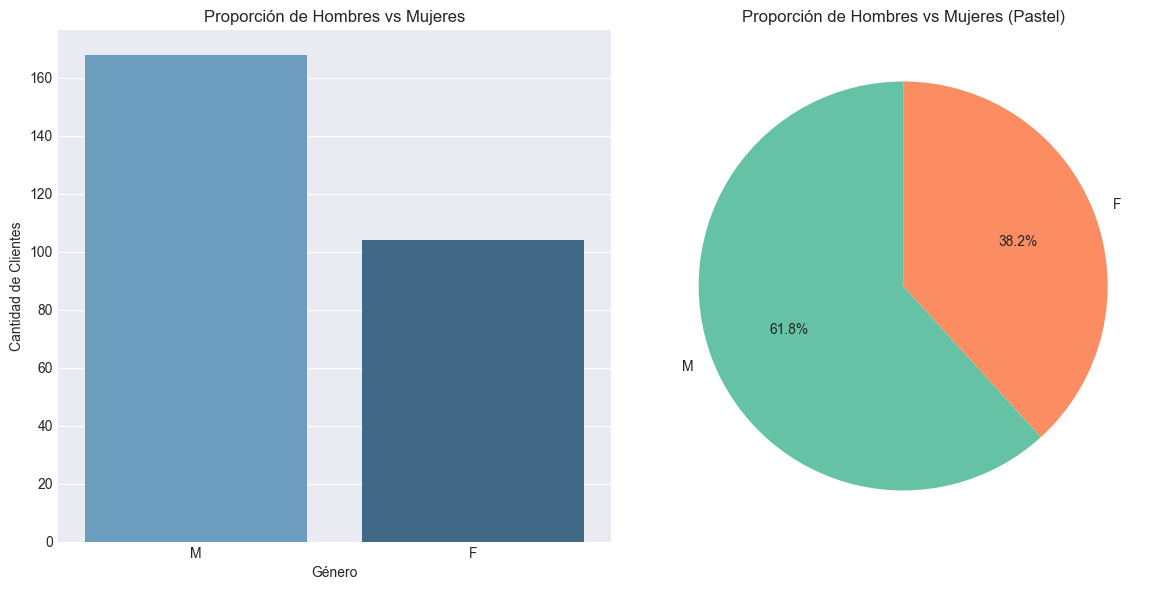

In [116]:
# Contando ocurrencias de "M" y "F" en la columna 'genero'
proporciones = df_modelo['genero'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Gráfico de barras
sns.barplot(x=proporciones.index, y=proporciones.values, palette="Blues_d", ax=axes[0])
axes[0].set_title('Proporción de Hombres vs Mujeres')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de Clientes')

# Gráfico de pastel
proporciones.plot.pie(autopct='%1.1f%%', startangle=90, ax=axes[1])
axes[1].set_title('Proporción de Hombres vs Mujeres (Pastel)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [117]:
MostrarSinLimite(df_modelo.head())

,id_masked,intentos_hist_linea_movil,intentos_hist_whatsapp,exitos_hist_linea_movil,exitos_hist_whatsapp,rpc_hist_linea_movil,rpc_hist_whatsapp,intentos_t_linea_movil,intentos_t_whatsapp,exitos_t_linea_movil,exitos_t_whatsapp,rpc_t_linea_movil,rpc_t_whatsapp,var_resp,fecha_mes,max_fecha_proceso,codigo_tipo_cliente,area_financiera,nombre_area_financiera,genero,estado_civil,es_hombre,casado,edad,antiguedad,cifcodocupaci,ocupacion,nsegmento,nsubsegmento,es_preferencial,es_asalariado,es_comercial,es_seg_personal,salario_total,tamano_comercial,clasificacion_fuente_ingreso,canal_mas_usado,en_lista_control,cifdeptdomici,cifciuddomici,flag_reestructurado,nivel_relacionamiento,status_cliente,entrada_efectivo_total,monto_remesas,activo_digital_1m,activo_digital_3m,activo_digital_omni_1m,activo_digital_omni_3m,activo_digital_bm_1m,activo_digital_bm_3m,estado_cuenta,tiene_omni,tiene_ebancaemp
0,-9.223003e+18,1.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-9.221978e+18,2.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-9.221561e+18,7.0,0.0,1.0,0.0,0.142857,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-9.221474e+18,2.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-9.221130e+18,4.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.0,0.0,1.0,0.0,0.5,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
MostrarSinLimite(df_modelo.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41487 entries, 0 to 41486
Data columns (total 54 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   id_masked                     41487 non-null  float64       
 1   intentos_hist_linea_movil     41487 non-null  float64       
 2   intentos_hist_whatsapp        41487 non-null  float64       
 3   exitos_hist_linea_movil       41487 non-null  float64       
 4   exitos_hist_whatsapp          41487 non-null  float64       
 5   rpc_hist_linea_movil          41487 non-null  float64       
 6   rpc_hist_whatsapp             41487 non-null  float64       
 7   intentos_t_linea_movil        41487 non-null  float64       
 8   intentos_t_whatsapp           41487 non-null  float64       
 9   exitos_t_linea_movil          41487 non-null  float64       
 10  exitos_t_whatsapp             41487 non-null  float64       
 11  rpc_t_linea_movil           

None

In [119]:
# Verificar nulos
nulos = df_modelo.isnull().sum()
nulos_importantes = nulos[nulos > 0].sort_values(ascending=False)

if len(nulos_importantes) > 0:
    print(f"\n Columnas con nulos ({len(nulos_importantes)}):")
    print(nulos_importantes.head(10))
else:
    print(f"\n✅ No hay valores nulos")

MostrarSinLimite(df_modelo.head(3))


 Columnas con nulos (40):
estado_cuenta             41258
fecha_mes                 41215
entrada_efectivo_total    41215
canal_mas_usado           41215
en_lista_control          41215
cifdeptdomici             41215
cifciuddomici             41215
flag_reestructurado       41215
nivel_relacionamiento     41215
status_cliente            41215
dtype: int64


,id_masked,intentos_hist_linea_movil,intentos_hist_whatsapp,exitos_hist_linea_movil,exitos_hist_whatsapp,rpc_hist_linea_movil,rpc_hist_whatsapp,intentos_t_linea_movil,intentos_t_whatsapp,exitos_t_linea_movil,exitos_t_whatsapp,rpc_t_linea_movil,rpc_t_whatsapp,var_resp,fecha_mes,max_fecha_proceso,codigo_tipo_cliente,area_financiera,nombre_area_financiera,genero,estado_civil,es_hombre,casado,edad,antiguedad,cifcodocupaci,ocupacion,nsegmento,nsubsegmento,es_preferencial,es_asalariado,es_comercial,es_seg_personal,salario_total,tamano_comercial,clasificacion_fuente_ingreso,canal_mas_usado,en_lista_control,cifdeptdomici,cifciuddomici,flag_reestructurado,nivel_relacionamiento,status_cliente,entrada_efectivo_total,monto_remesas,activo_digital_1m,activo_digital_3m,activo_digital_omni_1m,activo_digital_omni_3m,activo_digital_bm_1m,activo_digital_bm_3m,estado_cuenta,tiene_omni,tiene_ebancaemp
0,-9.223003e+18,1.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-9.221978e+18,2.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-9.221561e+18,7.0,0.0,1.0,0.0,0.142857,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. ANÁLISIS EXPLORATORIO (EDA)


 Calculando correlaciones para 39 features:
   - Features RPC: 6
   - Features demográficas numéricas: 32
   - Variable respuesta: 1

   Total: 39 variables



 Calculando correlaciones para 39 features:
   - Features RPC: 6
   - Features demográficas numéricas: 32
   - Variable respuesta: 1

   Total: 39 variables


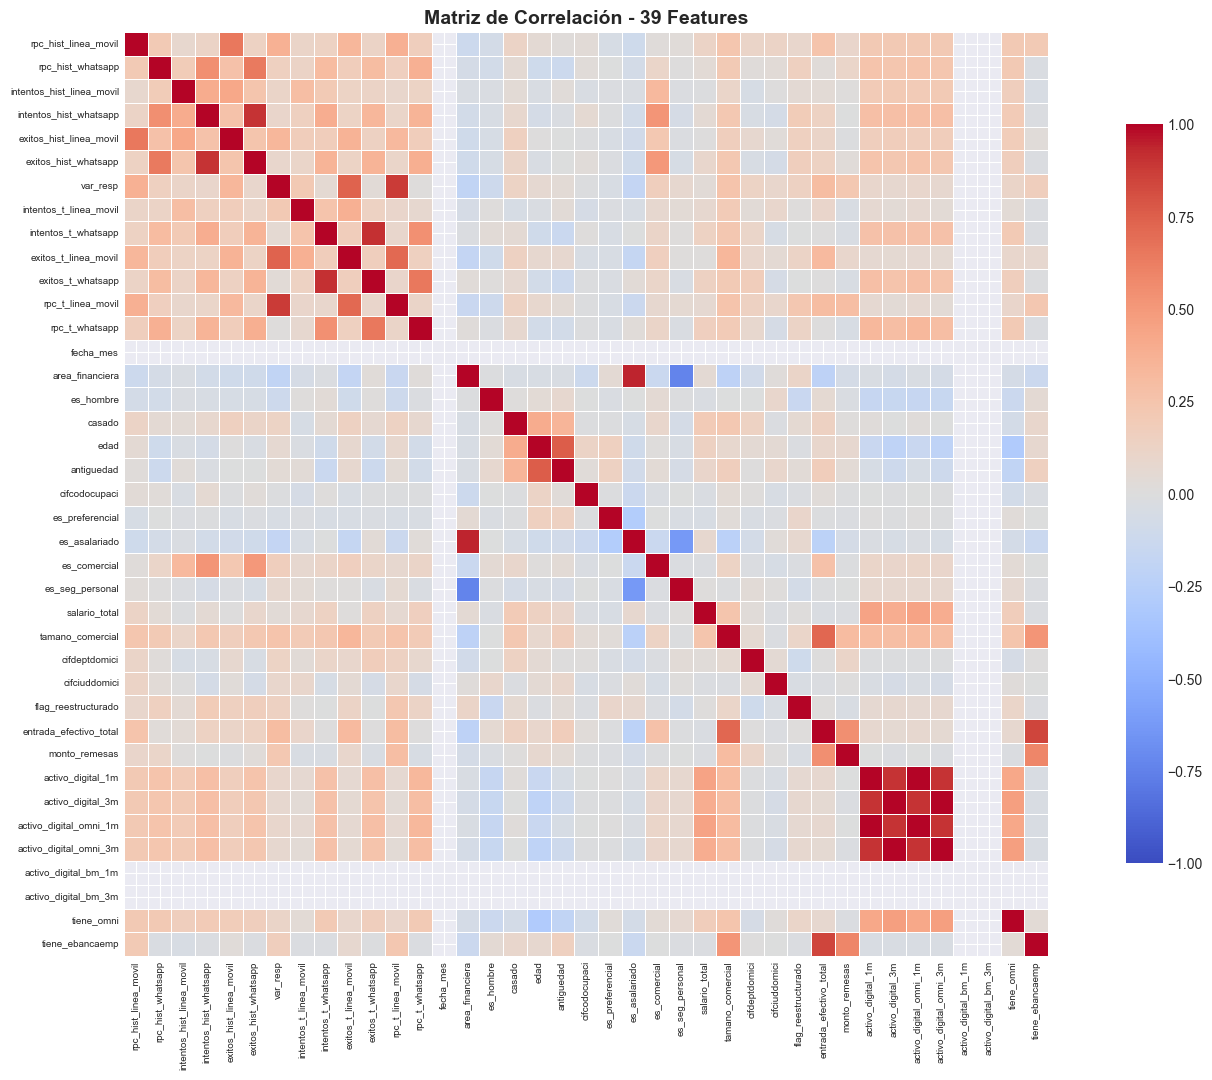

In [120]:
# Matriz de Correlaciones

# Seleccionar features numéricas (RPC históricas + TODAS las demográficas numéricas)

features_para_corr = ['rpc_hist_linea_movil', 'rpc_hist_whatsapp', 
                      'intentos_hist_linea_movil', 'intentos_hist_whatsapp',
                      'exitos_hist_linea_movil', 'exitos_hist_whatsapp',
                      'var_resp']

# Agregar TODAS las features demográficas numéricas
features_demo_num = df_modelo.select_dtypes(include=[np.number]).columns.tolist()
features_demo_num = [c for c in features_demo_num 
                     if c not in features_para_corr + ['id_masked']]

# Agregar TODAS
features_para_corr.extend(features_demo_num)

# Filtrar solo las que existen en df_modelo
features_para_corr = [f for f in features_para_corr if f in df_modelo.columns]

print(f"\n Calculando correlaciones para {len(features_para_corr)} features:")
print(f"   - Features RPC: 6")
print(f"   - Features demográficas numéricas: {len(features_demo_num)}")
print(f"   - Variable respuesta: 1")
print(f"\n   Total: {len(features_para_corr)} variables")

# Calcular matriz de correlación
corr_matrix = df_modelo[features_para_corr].corr()

# Visualización - Heatmap completo (solo si no hay demasiadas features)
if len(features_para_corr) <= 30:
    plt.figure(figsize=(18, 8))
    
    # Heatmap completo
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, annot_kws={'fontsize': 8})
    plt.title('Matriz de Correlación - Todas las Features', 
              fontweight='bold', fontsize=13)
    plt.tick_params(axis='both', labelsize=8)
else:
    # Si hay muchas features, solo mostrar heatmap sin anotaciones
    plt.figure(figsize=(20, 12))
    
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1)
    plt.title(f'Matriz de Correlación - {len(features_para_corr)} Features', 
                      fontweight='bold', fontsize=14)
    plt.tick_params(axis='both', labelsize=7)

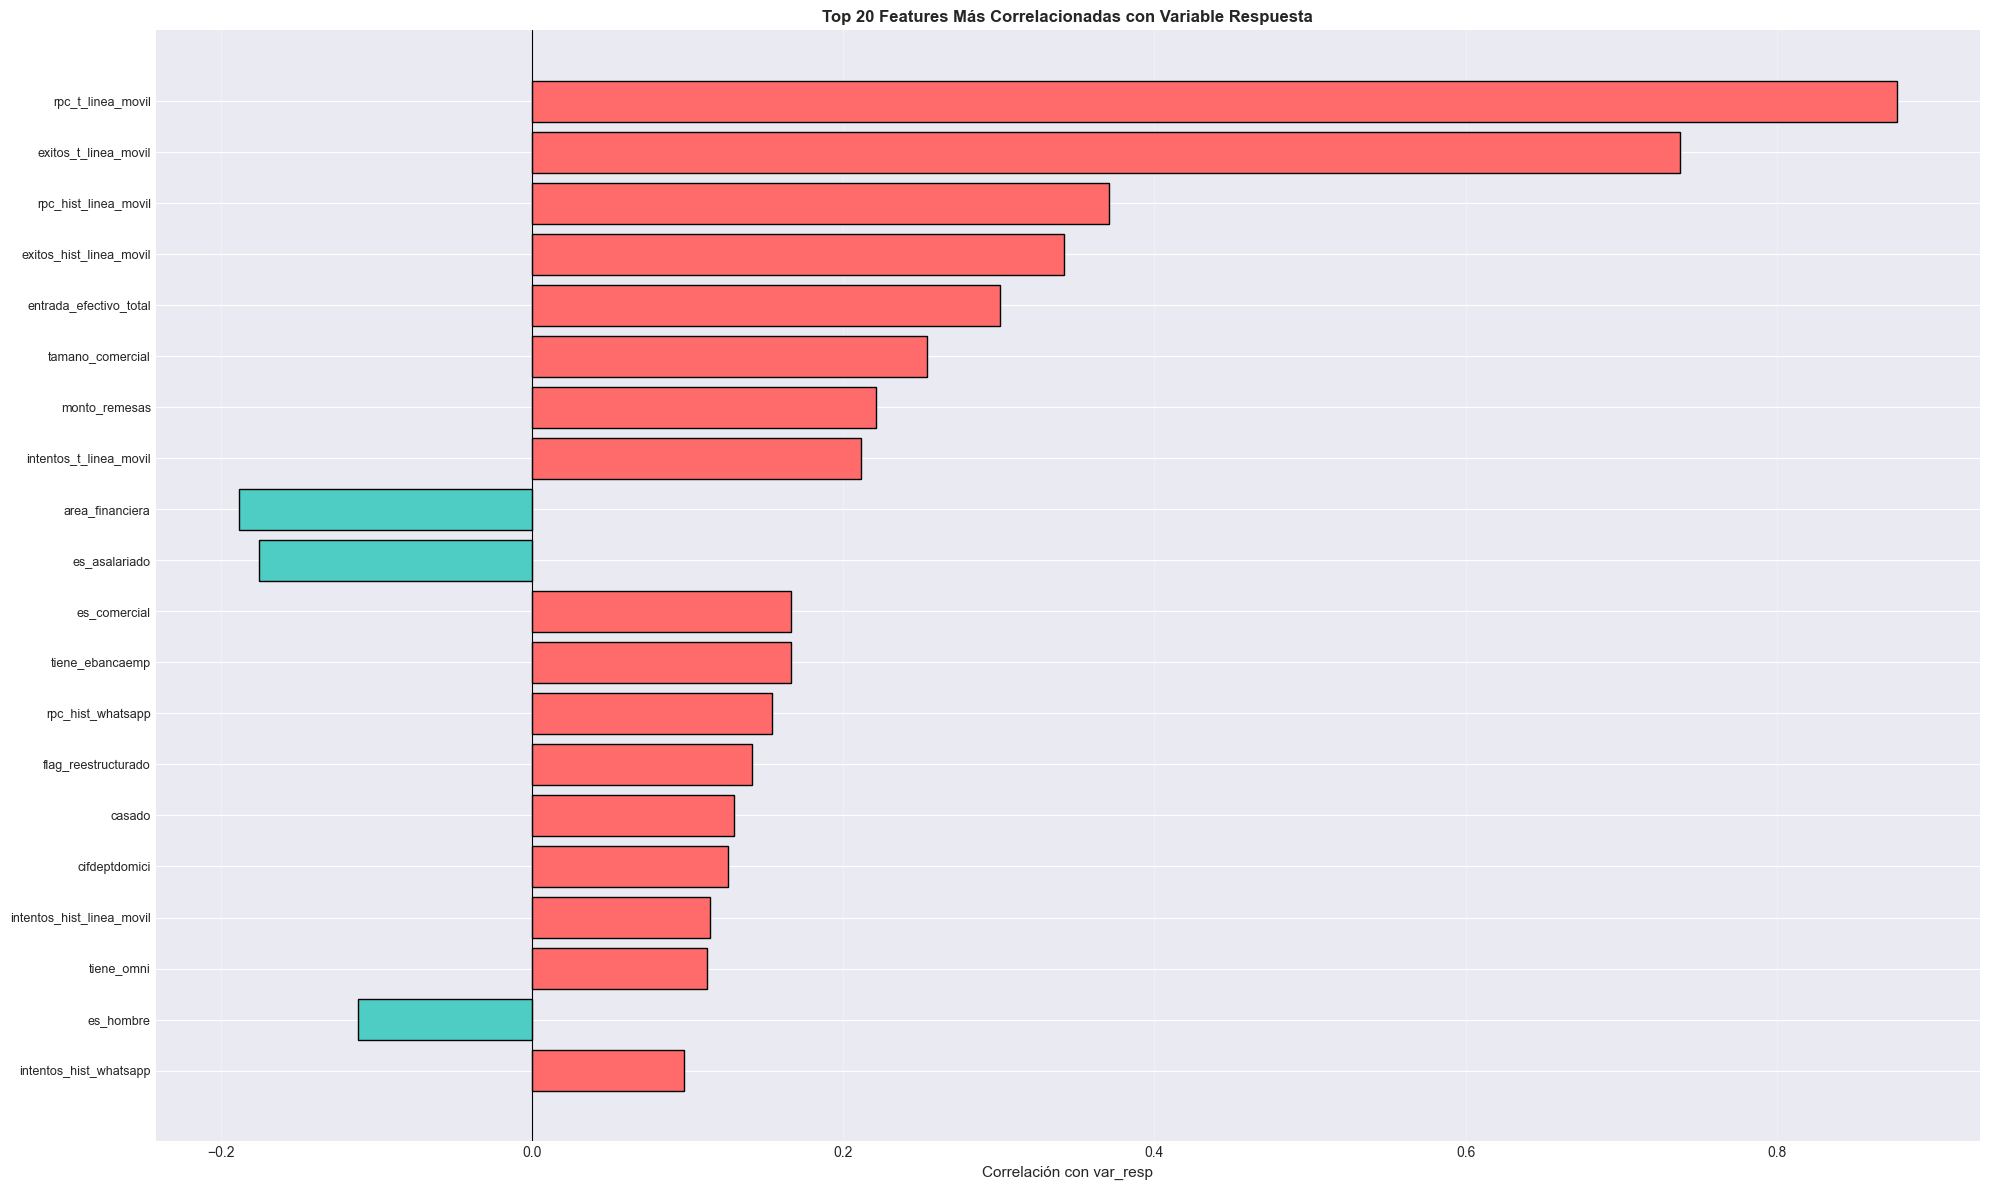

In [121]:

plt.figure(figsize=(20, 12))

# Correlaciones con var_resp
corr_con_target = corr_matrix['var_resp'].drop('var_resp').sort_values(ascending=False)
colors_bars = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in corr_con_target]

# Limitar el gráfico de barras a las top 20 features más correlacionadas
top_n = min(20, len(corr_con_target))
top_corr_abs = corr_con_target.abs().sort_values(ascending=False).head(top_n)
top_corr_display = corr_con_target[top_corr_abs.index]
colors_top = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in top_corr_display]

plt.barh(range(len(top_corr_display)), top_corr_display, color=colors_top, edgecolor='black')
plt.yticks(range(len(top_corr_display)), top_corr_display.index, fontsize=9)
plt.xlabel('Correlación con var_resp', fontsize=11)
plt.title(f'Top {top_n} Features Más Correlacionadas con Variable Respuesta', 
          fontweight='bold', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [122]:
#  Estudio Detallado de Valores Nulos

# Análisis general de nulos
nulls_total = df_modelo.isnull().sum()
nulls_pct = (nulls_total / len(df_modelo) * 100).round(2)

df_nulls = pd.DataFrame({
    'columna': nulls_total.index,
    'nulos': nulls_total.values,
    'porcentaje': nulls_pct.values,
    'no_nulos': len(df_modelo) - nulls_total.values,
    'total': len(df_modelo)
})

# Filtrar solo columnas con nulos
df_nulls_con_nulos = df_nulls[df_nulls['nulos'] > 0].sort_values('nulos', ascending=False)

if len(df_nulls_con_nulos) > 0:
    print(f"\n COLUMNAS CON VALORES NULOS ({len(df_nulls_con_nulos)} columnas):")
    print("="*70)
    MostrarSinLimite(df_nulls_con_nulos)
    
    



 COLUMNAS CON VALORES NULOS (40 columnas):


,columna,nulos,porcentaje,no_nulos,total
51,estado_cuenta,41258,99.45,229,41487
14,fecha_mes,41215,99.34,272,41487
43,entrada_efectivo_total,41215,99.34,272,41487
36,canal_mas_usado,41215,99.34,272,41487
37,en_lista_control,41215,99.34,272,41487
38,cifdeptdomici,41215,99.34,272,41487
39,cifciuddomici,41215,99.34,272,41487
40,flag_reestructurado,41215,99.34,272,41487
41,nivel_relacionamiento,41215,99.34,272,41487
42,status_cliente,41215,99.34,272,41487



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,272.0,41.908088,13.105125,21.0,33.0,39.0,51.0,81.0



 Distribución por Variable Respuesta:



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


...

,count,mean,median,std,min,max
WhatsApp mejor (0),240,41.60,38.0,13.35,21.0,81.0
Línea Móvil mejor (1),32,44.22,45.0,10.98,23.0,68.0



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,272.0,41.908088,13.105125,21.0,33.0,39.0,51.0,81.0



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,41.60,38.0,13.35,21.0,81.0
Línea Móvil mejor (1),32,44.22,45.0,10.98,23.0,68.0


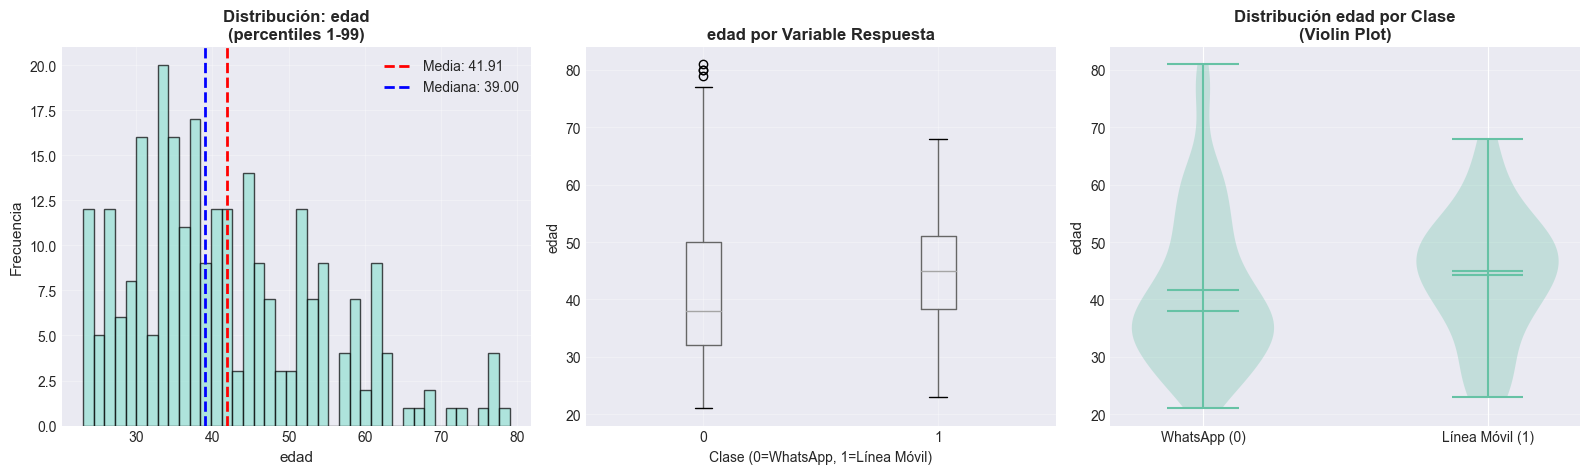


 Información General:
   Tipo de dato: object
   Valores únicos: 2
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,M,168,61.76
1,F,104,38.24



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,272.0,41.908088,13.105125,21.0,33.0,39.0,51.0,81.0



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,41.60,38.0,13.35,21.0,81.0
Línea Móvil mejor (1),32,44.22,45.0,10.98,23.0,68.0


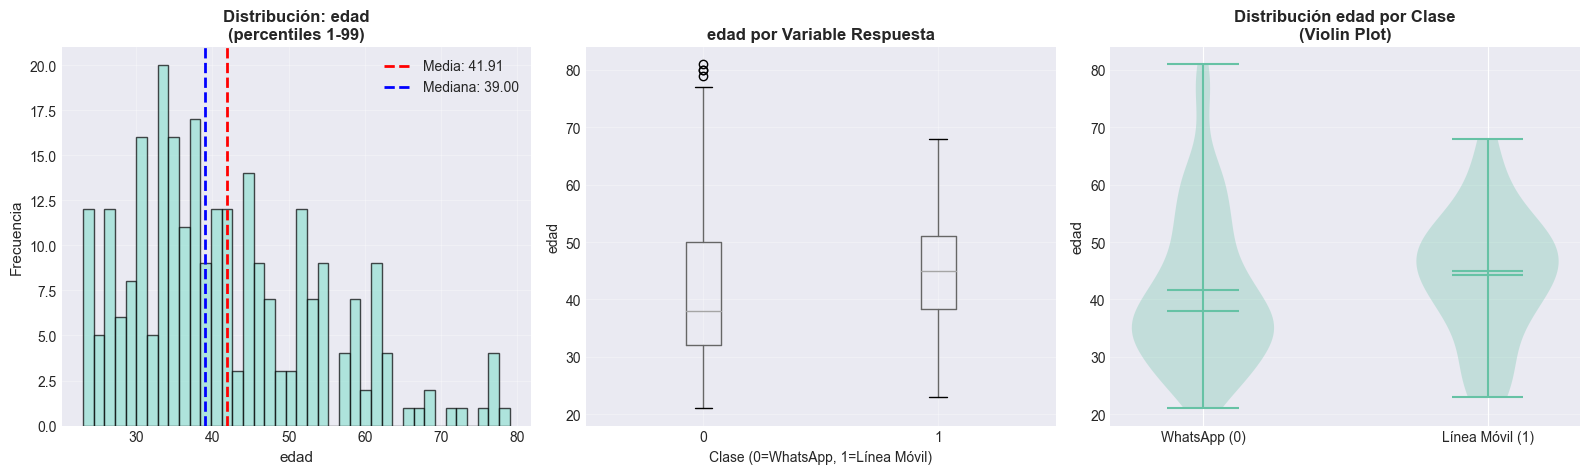


 Información General:
   Tipo de dato: object
   Valores únicos: 2
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,M,168,61.76
1,F,104,38.24



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
genero,,
F,83.65,16.35
M,91.07,8.93
All,88.24,11.76



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,272.0,41.908088,13.105125,21.0,33.0,39.0,51.0,81.0



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,41.60,38.0,13.35,21.0,81.0
Línea Móvil mejor (1),32,44.22,45.0,10.98,23.0,68.0


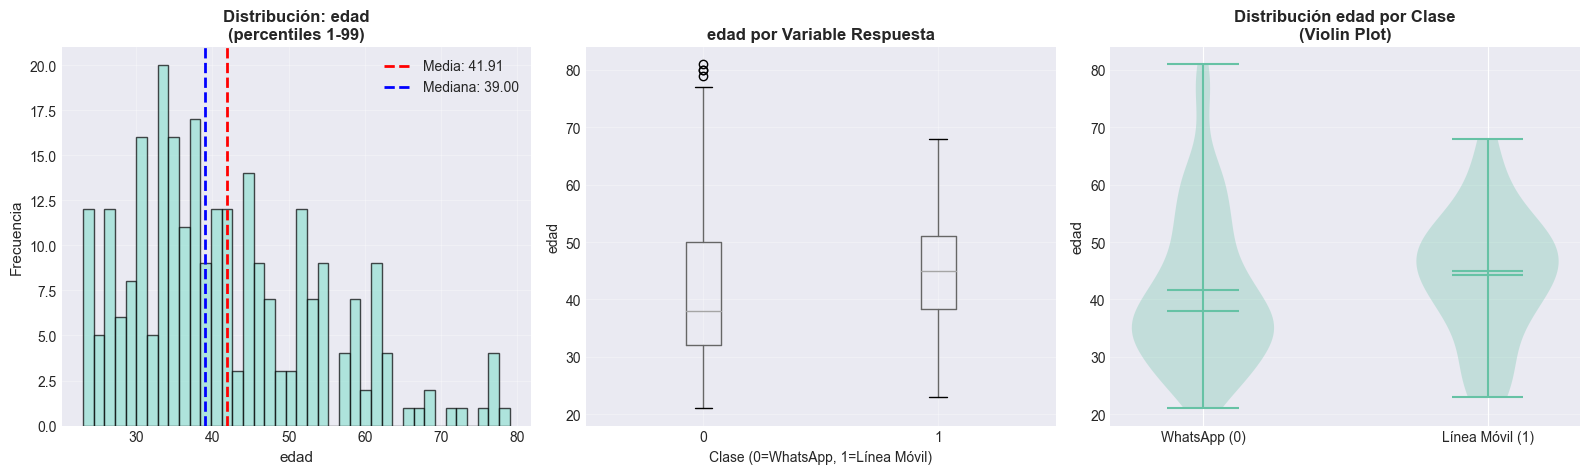


 Información General:
   Tipo de dato: object
   Valores únicos: 2
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,M,168,61.76
1,F,104,38.24



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
genero,,
F,83.65,16.35
M,91.07,8.93
All,88.24,11.76


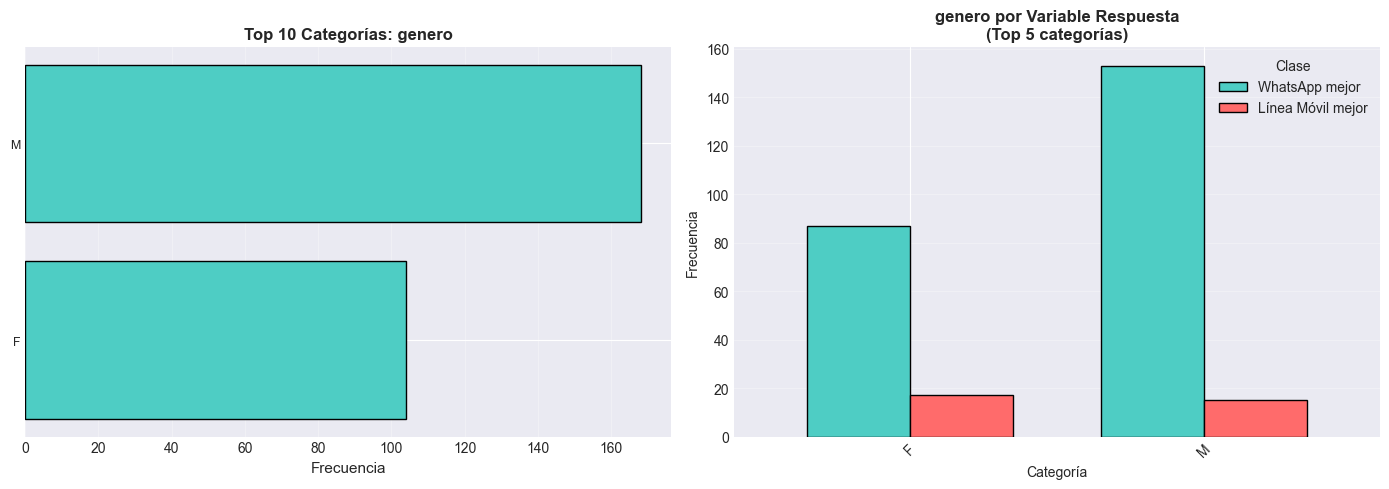


 Información General:
   Tipo de dato: object
   Valores únicos: 6
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,ASALARIADO,227,83.46
1,NO TIENE O SIN INFO,25,9.19
2,ASALARIADO NO COTIZANTE,13,4.78
3,REMESA EXTERIOR,4,1.47
4,ESTUDIANTE,2,0.74
5,OTROS TIPOS DE CLIENTE,1,0.37



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,272.0,41.908088,13.105125,21.0,33.0,39.0,51.0,81.0



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,41.60,38.0,13.35,21.0,81.0
Línea Móvil mejor (1),32,44.22,45.0,10.98,23.0,68.0


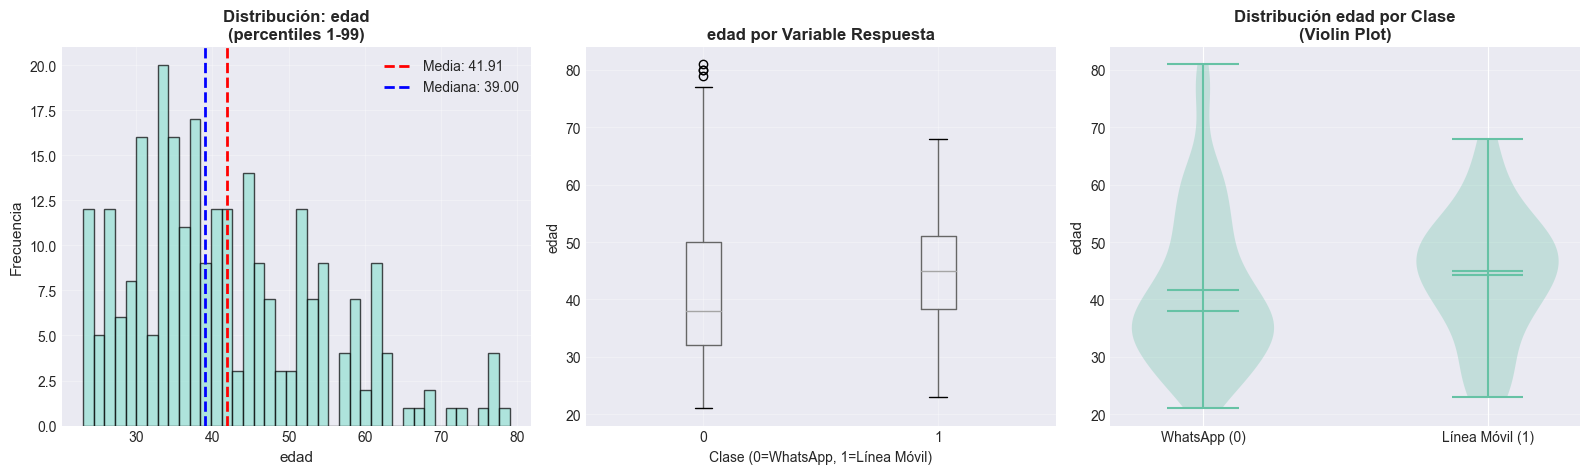


 Información General:
   Tipo de dato: object
   Valores únicos: 2
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,M,168,61.76
1,F,104,38.24



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
genero,,
F,83.65,16.35
M,91.07,8.93
All,88.24,11.76


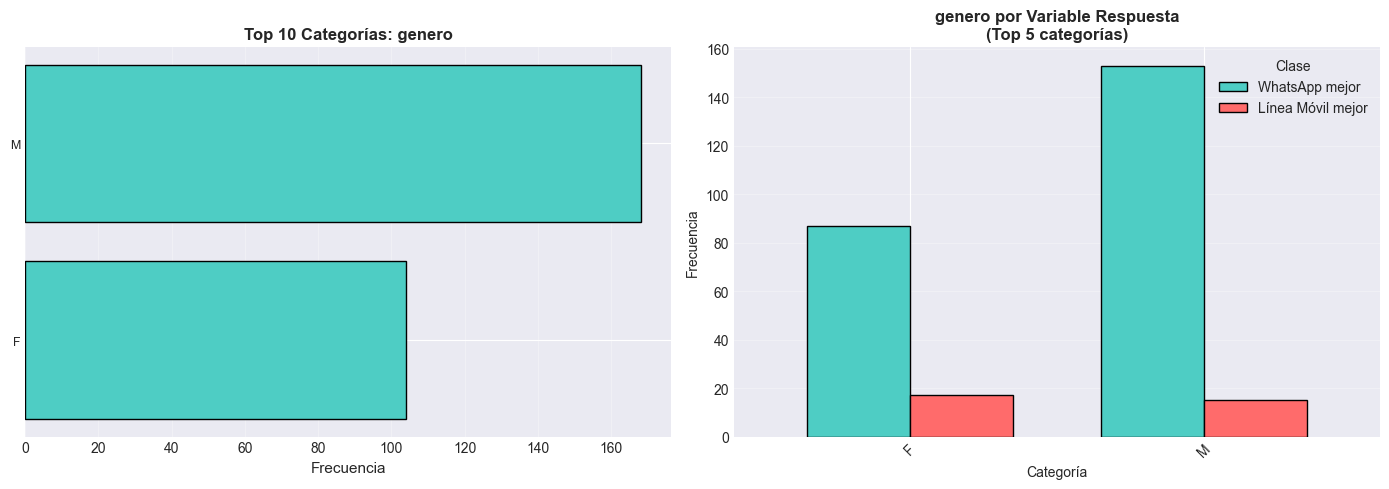


 Información General:
   Tipo de dato: object
   Valores únicos: 6
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,ASALARIADO,227,83.46
1,NO TIENE O SIN INFO,25,9.19
2,ASALARIADO NO COTIZANTE,13,4.78
3,REMESA EXTERIOR,4,1.47
4,ESTUDIANTE,2,0.74
5,OTROS TIPOS DE CLIENTE,1,0.37



 Distribución Cruzada con Variable Respuesta:



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,272.0,41.908088,13.105125,21.0,33.0,39.0,51.0,81.0



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,41.60,38.0,13.35,21.0,81.0
Línea Móvil mejor (1),32,44.22,45.0,10.98,23.0,68.0


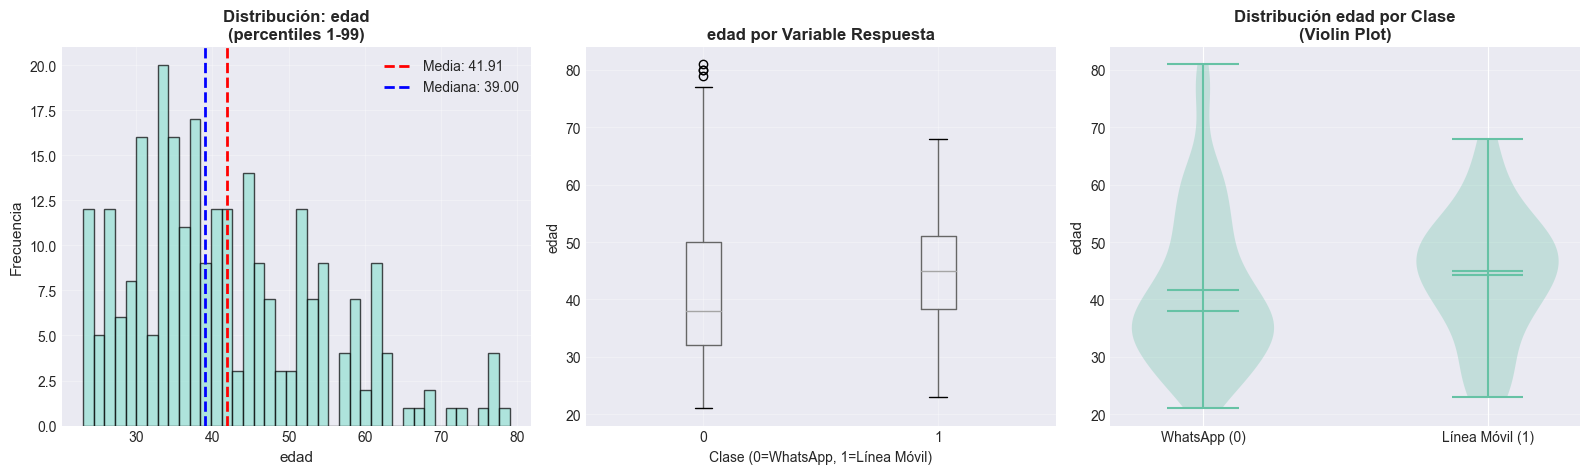


 Información General:
   Tipo de dato: object
   Valores únicos: 2
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,M,168,61.76
1,F,104,38.24



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
genero,,
F,83.65,16.35
M,91.07,8.93
All,88.24,11.76


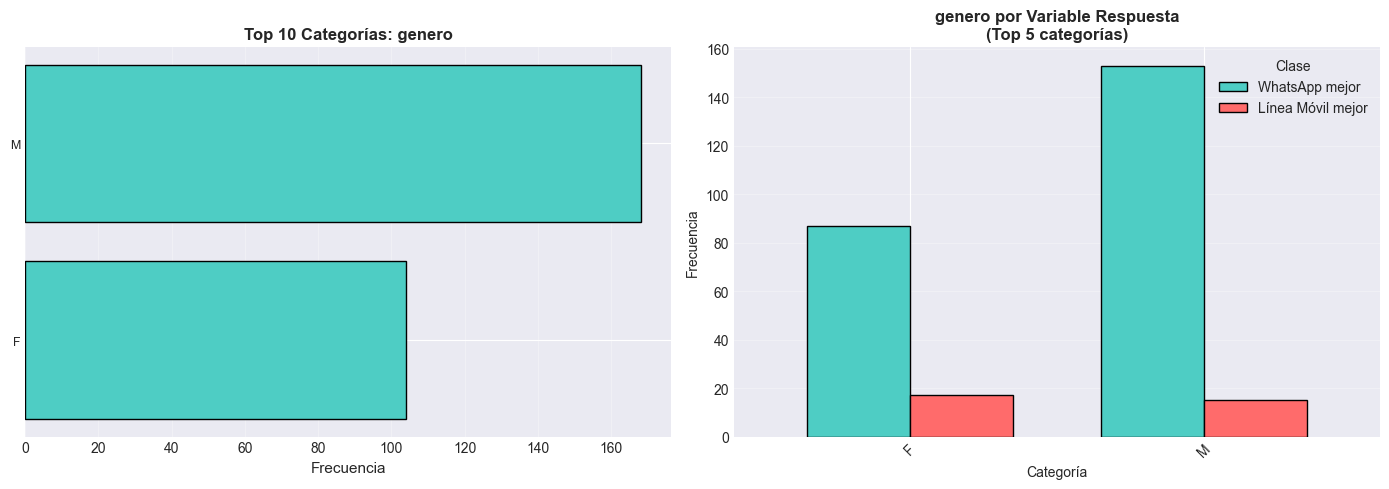


 Información General:
   Tipo de dato: object
   Valores únicos: 6
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,ASALARIADO,227,83.46
1,NO TIENE O SIN INFO,25,9.19
2,ASALARIADO NO COTIZANTE,13,4.78
3,REMESA EXTERIOR,4,1.47
4,ESTUDIANTE,2,0.74
5,OTROS TIPOS DE CLIENTE,1,0.37



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
clasificacion_fuente_ingreso,,
ASALARIADO,90.75,9.25
ASALARIADO NO COTIZANTE,84.62,15.38
ESTUDIANTE,100.00,0.00
NO TIENE O SIN INFO,72.00,28.00
OTROS TIPOS DE CLIENTE,100.00,0.00
REMESA EXTERIOR,50.00,50.00
All,88.24,11.76



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,272.0,41.908088,13.105125,21.0,33.0,39.0,51.0,81.0



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,41.60,38.0,13.35,21.0,81.0
Línea Móvil mejor (1),32,44.22,45.0,10.98,23.0,68.0


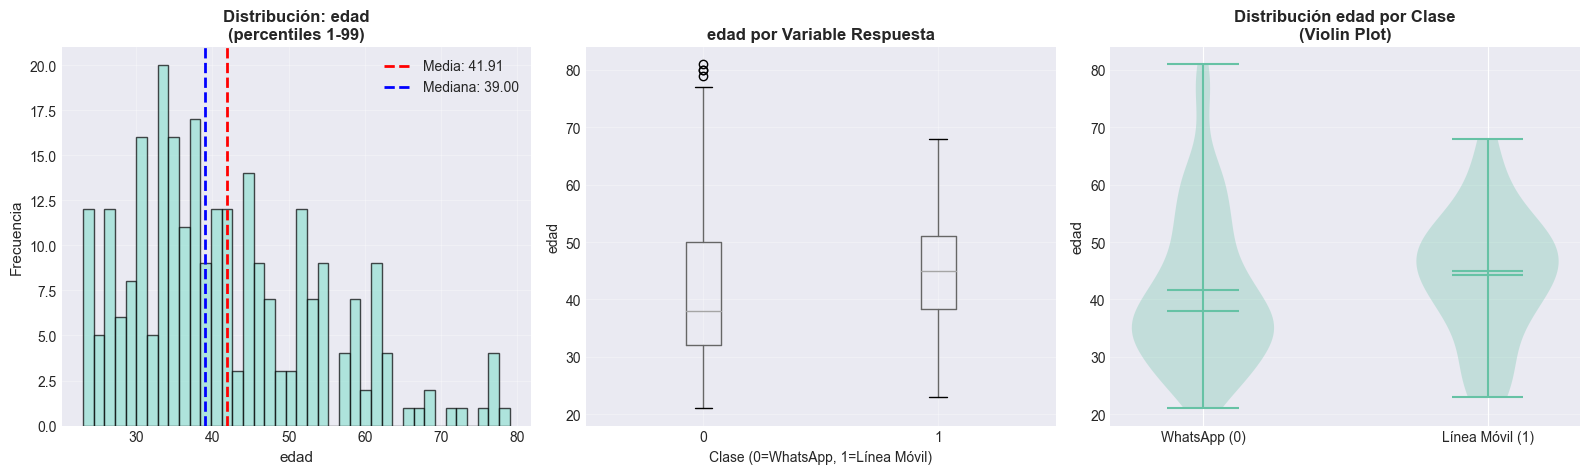


 Información General:
   Tipo de dato: object
   Valores únicos: 2
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,M,168,61.76
1,F,104,38.24



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
genero,,
F,83.65,16.35
M,91.07,8.93
All,88.24,11.76


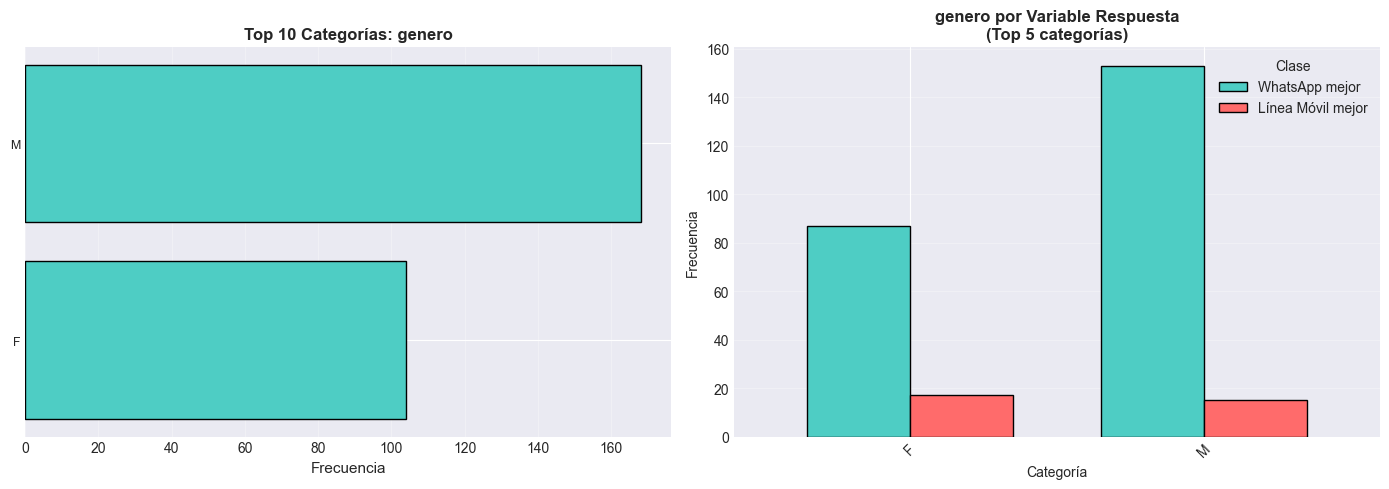


 Información General:
   Tipo de dato: object
   Valores únicos: 6
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,ASALARIADO,227,83.46
1,NO TIENE O SIN INFO,25,9.19
2,ASALARIADO NO COTIZANTE,13,4.78
3,REMESA EXTERIOR,4,1.47
4,ESTUDIANTE,2,0.74
5,OTROS TIPOS DE CLIENTE,1,0.37



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
clasificacion_fuente_ingreso,,
ASALARIADO,90.75,9.25
ASALARIADO NO COTIZANTE,84.62,15.38
ESTUDIANTE,100.00,0.00
NO TIENE O SIN INFO,72.00,28.00
OTROS TIPOS DE CLIENTE,100.00,0.00
REMESA EXTERIOR,50.00,50.00
All,88.24,11.76


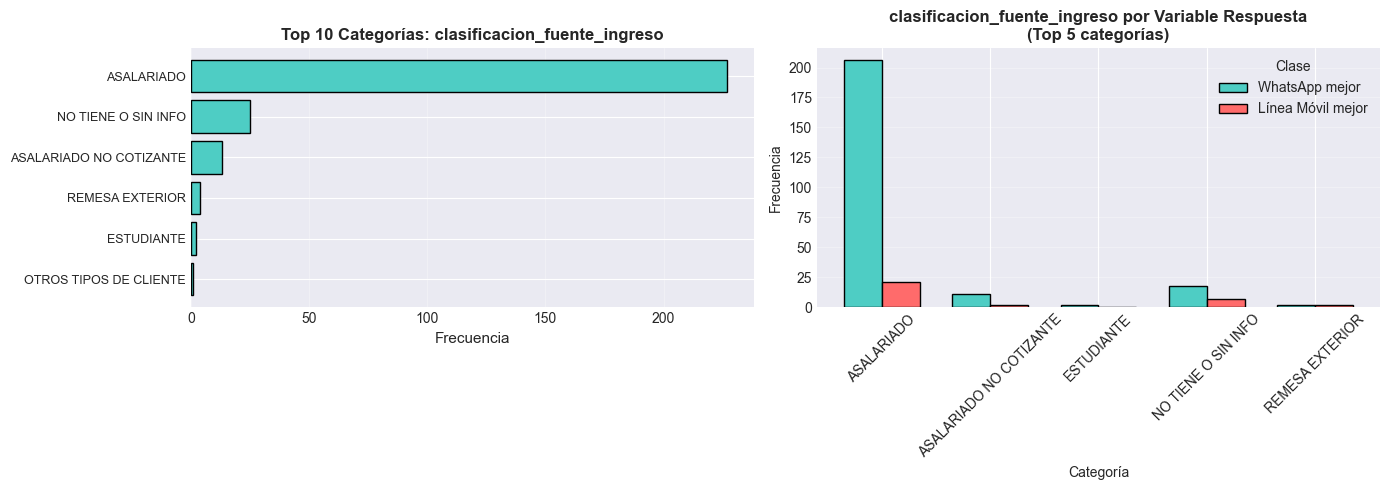


 Información General:
   Tipo de dato: float64
   Valores únicos: 41
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
salario_total,272.0,84.31239,253.80038,0.0,0.0,0.0,0.0,1716.68



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,272.0,41.908088,13.105125,21.0,33.0,39.0,51.0,81.0



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,41.60,38.0,13.35,21.0,81.0
Línea Móvil mejor (1),32,44.22,45.0,10.98,23.0,68.0


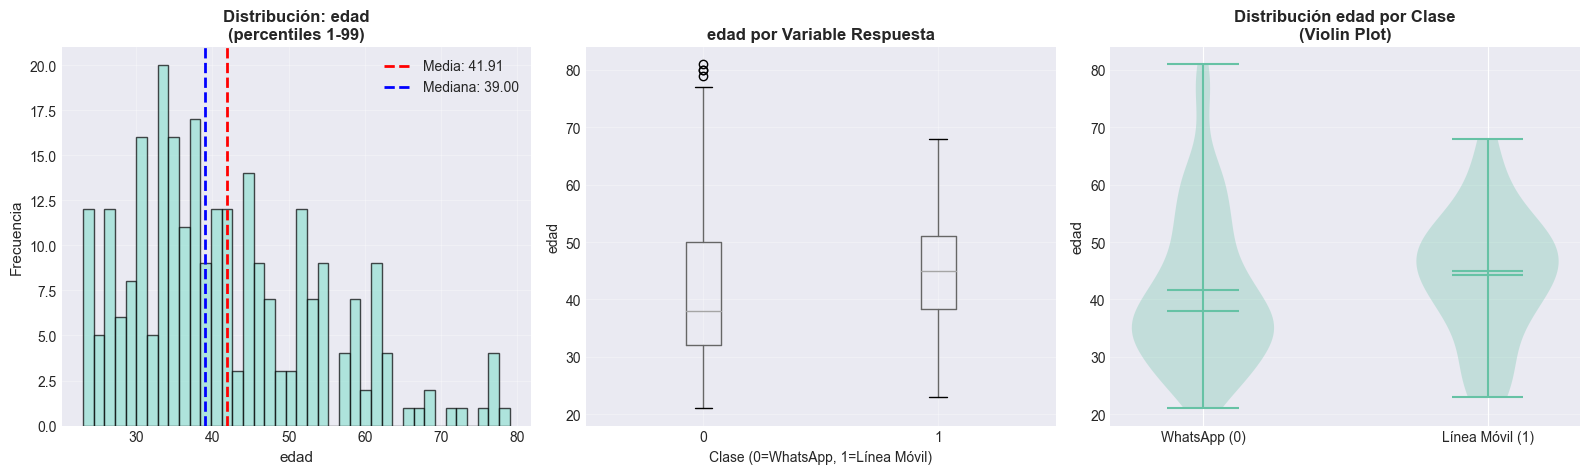


 Información General:
   Tipo de dato: object
   Valores únicos: 2
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,M,168,61.76
1,F,104,38.24



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
genero,,
F,83.65,16.35
M,91.07,8.93
All,88.24,11.76


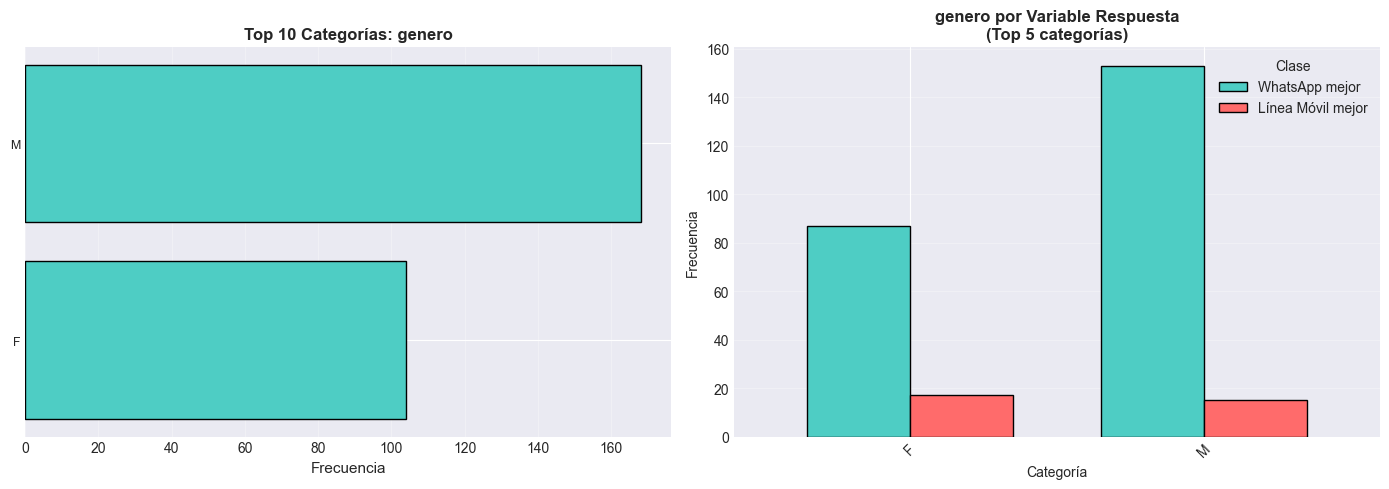


 Información General:
   Tipo de dato: object
   Valores únicos: 6
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,ASALARIADO,227,83.46
1,NO TIENE O SIN INFO,25,9.19
2,ASALARIADO NO COTIZANTE,13,4.78
3,REMESA EXTERIOR,4,1.47
4,ESTUDIANTE,2,0.74
5,OTROS TIPOS DE CLIENTE,1,0.37



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
clasificacion_fuente_ingreso,,
ASALARIADO,90.75,9.25
ASALARIADO NO COTIZANTE,84.62,15.38
ESTUDIANTE,100.00,0.00
NO TIENE O SIN INFO,72.00,28.00
OTROS TIPOS DE CLIENTE,100.00,0.00
REMESA EXTERIOR,50.00,50.00
All,88.24,11.76


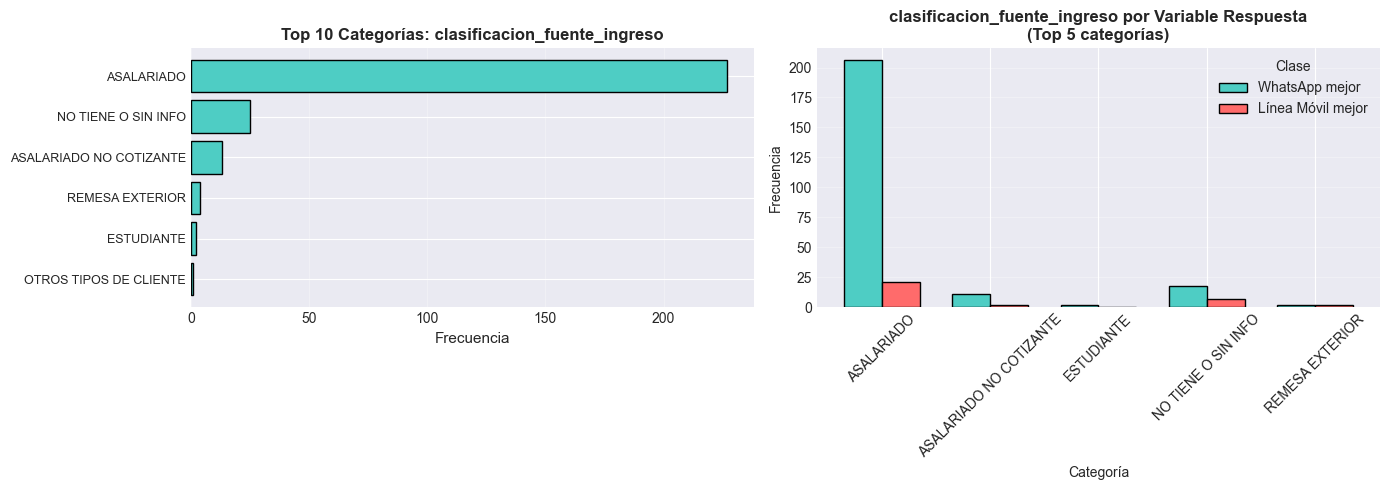


 Información General:
   Tipo de dato: float64
   Valores únicos: 41
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
salario_total,272.0,84.31239,253.80038,0.0,0.0,0.0,0.0,1716.68



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,81.22,0.0,252.49,0.0,1716.68
Línea Móvil mejor (1),32,107.53,0.0,266.39,0.0,1159.13



 Información General:
   Tipo de dato: float64
   Valores únicos: 52
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,272.0,41.908088,13.105125,21.0,33.0,39.0,51.0,81.0



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,41.60,38.0,13.35,21.0,81.0
Línea Móvil mejor (1),32,44.22,45.0,10.98,23.0,68.0


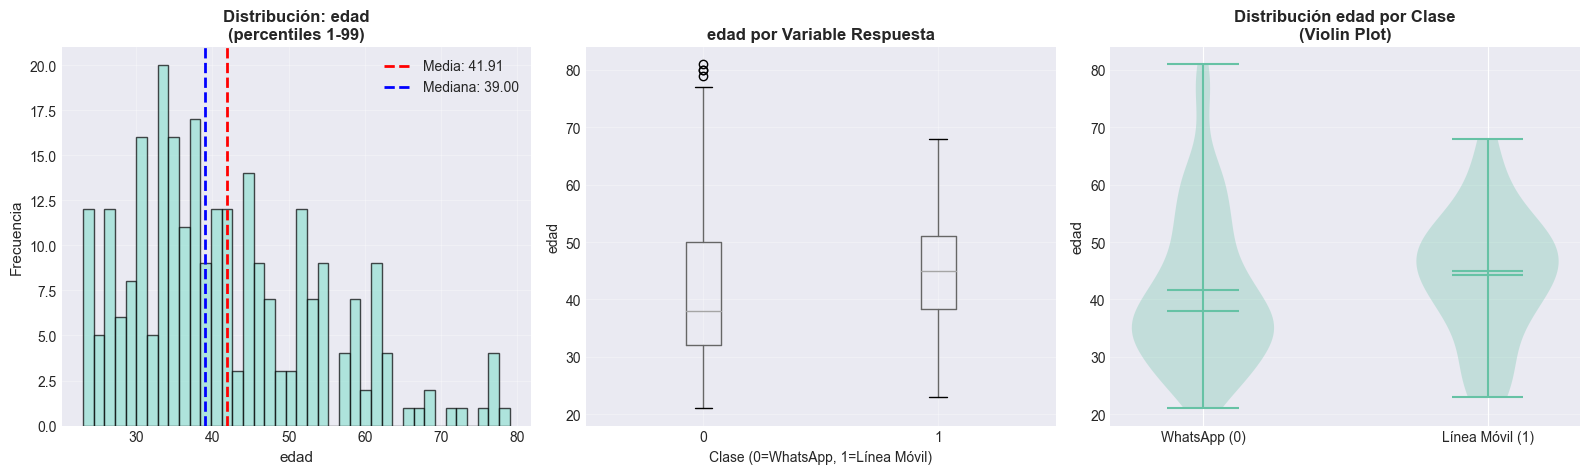


 Información General:
   Tipo de dato: object
   Valores únicos: 2
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,M,168,61.76
1,F,104,38.24



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
genero,,
F,83.65,16.35
M,91.07,8.93
All,88.24,11.76


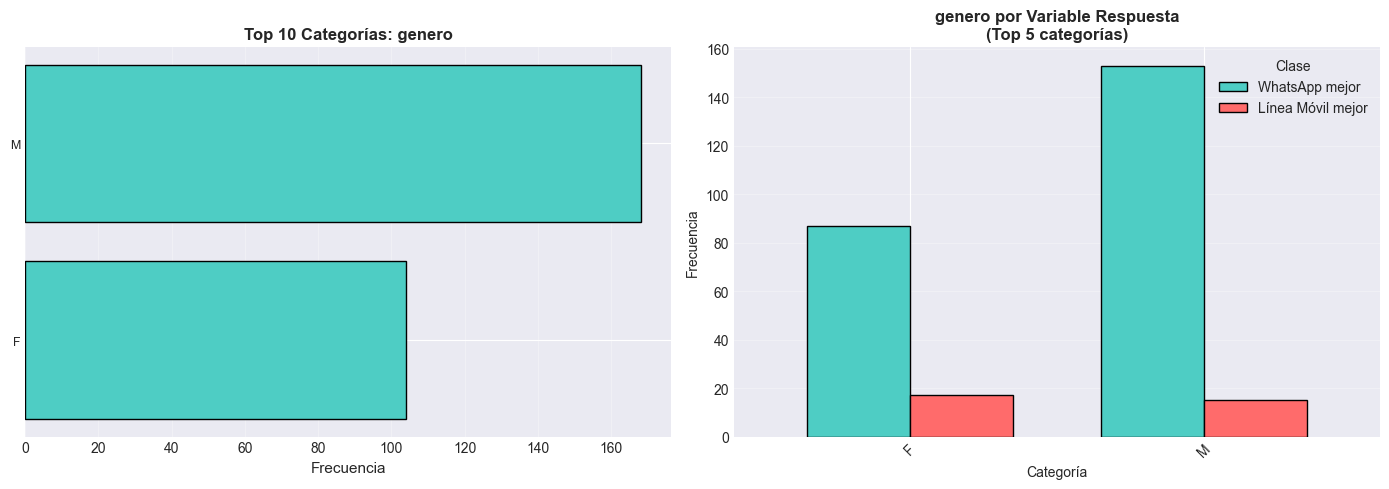


 Información General:
   Tipo de dato: object
   Valores únicos: 6
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Distribución de Valores:


,categoria,frecuencia,porcentaje
0,ASALARIADO,227,83.46
1,NO TIENE O SIN INFO,25,9.19
2,ASALARIADO NO COTIZANTE,13,4.78
3,REMESA EXTERIOR,4,1.47
4,ESTUDIANTE,2,0.74
5,OTROS TIPOS DE CLIENTE,1,0.37



 Distribución Cruzada con Variable Respuesta:


,WhatsApp mejor (%),Línea Móvil mejor (%)
clasificacion_fuente_ingreso,,
ASALARIADO,90.75,9.25
ASALARIADO NO COTIZANTE,84.62,15.38
ESTUDIANTE,100.00,0.00
NO TIENE O SIN INFO,72.00,28.00
OTROS TIPOS DE CLIENTE,100.00,0.00
REMESA EXTERIOR,50.00,50.00
All,88.24,11.76


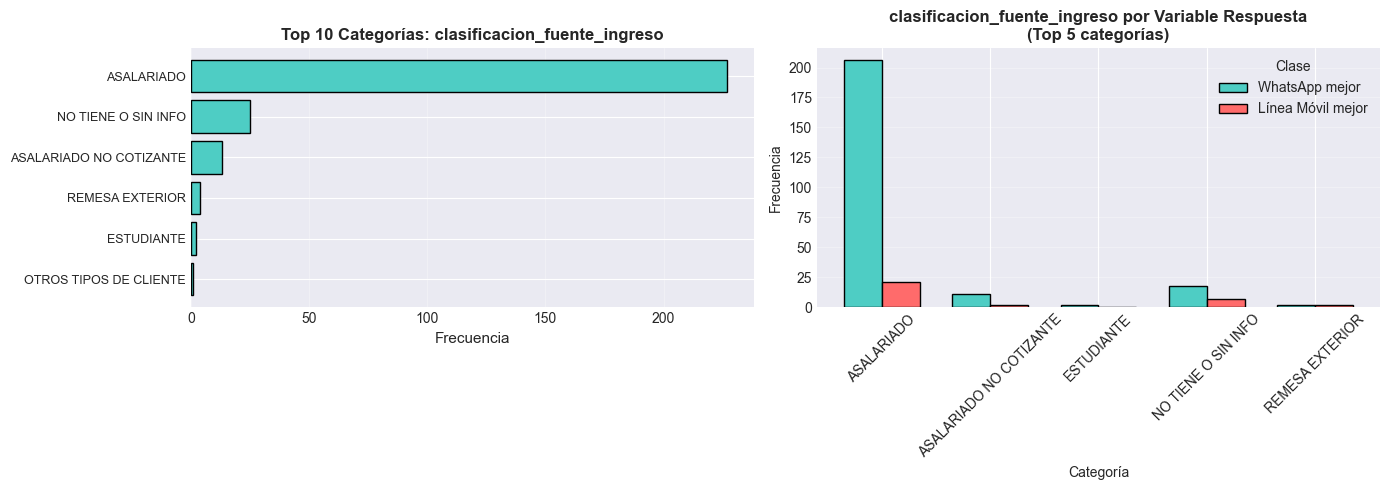


 Información General:
   Tipo de dato: float64
   Valores únicos: 41
   Valores nulos: 41,215 (99.34%)
   Valores no nulos: 272

 Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
salario_total,272.0,84.31239,253.80038,0.0,0.0,0.0,0.0,1716.68



 Distribución por Variable Respuesta:


,count,mean,median,std,min,max
WhatsApp mejor (0),240,81.22,0.0,252.49,0.0,1716.68
Línea Móvil mejor (1),32,107.53,0.0,266.39,0.0,1159.13


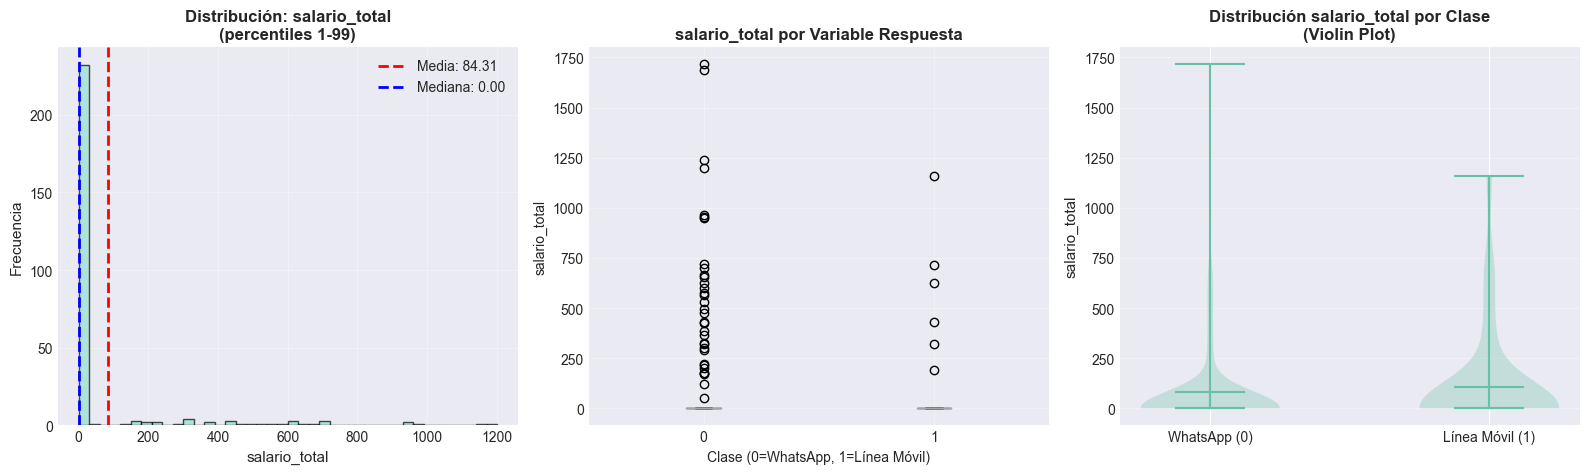

In [123]:
# 4.8 Estadísticas por Variables Demográficas Clave

# Columnas de interés
cols_interes = ['edad', 'genero', 'clasificacion_fuente_ingreso', 'salario_total']


# Análisis por cada columna disponible
for col in cols_interes:  
    # Información básica
    print(f"\n Información General:")
    print(f"   Tipo de dato: {df_modelo[col].dtype}")
    print(f"   Valores únicos: {df_modelo[col].nunique():,}")
    print(f"   Valores nulos: {df_modelo[col].isnull().sum():,} ({df_modelo[col].isnull().sum()/len(df_modelo)*100:.2f}%)")
    print(f"   Valores no nulos: {df_modelo[col].notna().sum():,}")
    
    # Si es numérica
    if df_modelo[col].dtype in ['int64', 'float64']:
        print(f"\n Estadísticas Descriptivas:")
        stats = df_modelo[col].describe()
        MostrarSinLimite(pd.DataFrame(stats).T)
        
        # Distribución por var_resp
        print(f"\n Distribución por Variable Respuesta:")
        stats_por_clase = df_modelo.groupby('var_resp')[col].agg([
            ('count', 'count'),
            ('mean', 'mean'),
            ('median', 'median'),
            ('std', 'std'),
            ('min', 'min'),
            ('max', 'max')
        ]).round(2)
        stats_por_clase.index = ['WhatsApp mejor (0)', 'Línea Móvil mejor (1)']
        MostrarSinLimite(stats_por_clase)
        
        # Visualización
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        # Histograma general
        data_no_null = df_modelo[col].dropna()
        q1 = data_no_null.quantile(0.01)
        q99 = data_no_null.quantile(0.99)
        data_filtered = data_no_null[(data_no_null >= q1) & (data_no_null <= q99)]
        
        axes[0].hist(data_filtered, bins=40, color='#95E1D3', edgecolor='black', alpha=0.7)
        axes[0].axvline(data_no_null.mean(), color='red', linestyle='--', linewidth=2, 
                       label=f'Media: {data_no_null.mean():.2f}')
        axes[0].axvline(data_no_null.median(), color='blue', linestyle='--', linewidth=2, 
                       label=f'Mediana: {data_no_null.median():.2f}')
        axes[0].set_xlabel(col, fontsize=11)
        axes[0].set_ylabel('Frecuencia', fontsize=11)
        axes[0].set_title(f'Distribución: {col}\n(percentiles 1-99)', fontweight='bold', fontsize=12)
        axes[0].legend()
        axes[0].grid(alpha=0.3)
        
        # Boxplot por clase
        df_modelo.boxplot(column=col, by='var_resp', ax=axes[1])
        axes[1].set_title(f'{col} por Variable Respuesta', fontweight='bold', fontsize=12)
        axes[1].set_xlabel('Clase (0=WhatsApp, 1=Línea Móvil)', fontsize=10)
        axes[1].set_ylabel(col, fontsize=10)
        axes[1].get_figure().suptitle('')
        axes[1].grid(alpha=0.3)
        
        # Violin plot
        data_plot = df_modelo[[col, 'var_resp']].dropna()
        parts = axes[2].violinplot(
            [data_plot[data_plot['var_resp']==0][col], 
             data_plot[data_plot['var_resp']==1][col]],
            positions=[0, 1],
            showmeans=True,
            showmedians=True
        )
        axes[2].set_xticks([0, 1])
        axes[2].set_xticklabels(['WhatsApp (0)', 'Línea Móvil (1)'])
        axes[2].set_ylabel(col, fontsize=11)
        axes[2].set_title(f'Distribución {col} por Clase\n(Violin Plot)', fontweight='bold', fontsize=12)
        axes[2].grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # Si es categórica
    else:
        print(f"\n Distribución de Valores:")
        value_counts = df_modelo[col].value_counts()
        value_counts_pct = df_modelo[col].value_counts(normalize=True) * 100
        
        df_dist = pd.DataFrame({
            'categoria': value_counts.index,
            'frecuencia': value_counts.values,
            'porcentaje': value_counts_pct.values.round(2)
        })
        MostrarSinLimite(df_dist.head(20))
        
        # Distribución por var_resp
        print(f"\n Distribución Cruzada con Variable Respuesta:")
        crosstab = pd.crosstab(df_modelo[col], df_modelo['var_resp'], 
                               margins=True, normalize='index') * 100
        crosstab = crosstab.round(2)
        # Solo 2 columnas porque normalize='index' no crea columna Total
        crosstab.columns = ['WhatsApp mejor (%)', 'Línea Móvil mejor (%)']
        MostrarSinLimite(crosstab.head(20))
        
        # Visualización (top 10 categorías)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Top categorías
        top_cats = value_counts.head(10)
        axes[0].barh(range(len(top_cats)), top_cats.values, color='#4ECDC4', edgecolor='black')
        axes[0].set_yticks(range(len(top_cats)))
        axes[0].set_yticklabels(top_cats.index, fontsize=9)
        axes[0].set_xlabel('Frecuencia', fontsize=11)
        axes[0].set_title(f'Top 10 Categorías: {col}', fontweight='bold', fontsize=12)
        axes[0].invert_yaxis()
        axes[0].grid(axis='x', alpha=0.3)
        
        # Distribución por var_resp (top 5 categorías)
        top_5_cats = value_counts.head(5).index
        df_top5 = df_modelo[df_modelo[col].isin(top_5_cats)]
        
        crosstab_top5 = pd.crosstab(df_top5[col], df_top5['var_resp'])
        crosstab_top5.plot(kind='bar', ax=axes[1], color=['#4ECDC4', '#FF6B6B'], 
                          edgecolor='black', width=0.7)
        axes[1].set_title(f'{col} por Variable Respuesta\n(Top 5 categorías)', 
                         fontweight='bold', fontsize=12)
        axes[1].set_xlabel('Categoría', fontsize=10)
        axes[1].set_ylabel('Frecuencia', fontsize=10)
        axes[1].legend(['WhatsApp mejor', 'Línea Móvil mejor'], title='Clase')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()


In [124]:
# 4.9 Análisis Temporal - Evolución de RPC por mes

# Verificar si tenemos columnas temporales disponibles
cols_temporales = [c for c in df_modelo.columns if 'fecha' in c.lower() or 'mes' in c.lower()]
print(f"\n Columnas temporales disponibles: {cols_temporales}")

# Análisis básico de estabilidad de RPC (si los datos históricos están agregados)
print(f"\n Estadísticas de variabilidad en RPC:")
print(f"\n   RPC Línea Móvil (histórico):")
print(f"      Media: {df_modelo['rpc_hist_linea_movil'].mean():.4f}")
print(f"      Std: {df_modelo['rpc_hist_linea_movil'].std():.4f}")
print(f"      CV: {(df_modelo['rpc_hist_linea_movil'].std() / df_modelo['rpc_hist_linea_movil'].mean()):.4f}")

print(f"\n   RPC WhatsApp (histórico):")
print(f"      Media: {df_modelo['rpc_hist_whatsapp'].mean():.4f}")
print(f"      Std: {df_modelo['rpc_hist_whatsapp'].std():.4f}")
print(f"      CV: {(df_modelo['rpc_hist_whatsapp'].std() / df_modelo['rpc_hist_whatsapp'].mean()):.4f}")



 Columnas temporales disponibles: ['fecha_mes', 'max_fecha_proceso', 'monto_remesas']

 Estadísticas de variabilidad en RPC:

   RPC Línea Móvil (histórico):
      Media: 0.0878
      Std: 0.2247
      CV: 2.5598

   RPC WhatsApp (histórico):
      Media: 0.0580
      Std: 0.1648
      CV: 2.8414


In [127]:
# INGENIERÍA DE FEATURES: Crear nuevas variables derivadas


# 1. Ratio RPC: Línea / WhatsApp
df_modelo['ratio_rpc'] = df_modelo['rpc_hist_linea_movil'] / (df_modelo['rpc_hist_whatsapp'] + 0.001)

# 2. Diferencia RPC: Línea - WhatsApp  
df_modelo['diff_rpc'] = df_modelo['rpc_hist_linea_movil'] - df_modelo['rpc_hist_whatsapp']

# 3. Total intentos históricos
df_modelo['total_intentos_hist'] = (
    df_modelo['intentos_hist_linea_movil'] + 
    df_modelo['intentos_hist_whatsapp']
)

# 4. Total éxitos históricos
df_modelo['total_exitos_hist'] = (
    df_modelo['exitos_hist_linea_movil'] + 
    df_modelo['exitos_hist_whatsapp']
)

# 5. RPC global (todos los canales)
df_modelo['rpc_global'] = (
    df_modelo['total_exitos_hist'] / 
    (df_modelo['total_intentos_hist'] + 0.001)
)

# 6. Mejor canal histórico (basado en RPC)
df_modelo['mejor_canal_historico'] = (
    df_modelo['rpc_hist_linea_movil'] > df_modelo['rpc_hist_whatsapp']
).astype(int)

# 7. Dominancia de canal (qué tan superior es un canal vs otro)
df_modelo['dominancia_canal'] = abs(
    df_modelo['rpc_hist_linea_movil'] - df_modelo['rpc_hist_whatsapp']
)



In [128]:


# Correlación de nuevas features con target
print(f"\n Correlación de features derivadas con var_resp:")
nuevas_features = ['ratio_rpc', 'diff_rpc', 'total_intentos_hist', 'total_exitos_hist', 
                   'rpc_global', 'mejor_canal_historico', 'dominancia_canal']
corr_nuevas = df_modelo[nuevas_features + ['var_resp']].corr()['var_resp'].drop('var_resp').sort_values(ascending=False)

for feat, corr_val in corr_nuevas.items():
    print(f"   {feat:30s}: {corr_val:>8.4f}")

print(f"\n {len(nuevas_features)} features derivadas creadas exitosamente")
print(f" Dataset actualizado: {df_modelo.shape}")


 Correlación de features derivadas con var_resp:
   rpc_global                    :   0.3729
   mejor_canal_historico         :   0.3463
   dominancia_canal              :   0.3324
   ratio_rpc                     :   0.3080
   total_exitos_hist             :   0.2349
   diff_rpc                      :   0.2316
   total_intentos_hist           :   0.1263

 7 features derivadas creadas exitosamente
 Dataset actualizado: (41487, 61)


## 5. PREPARACIÓN DE DATOS PARA MODELADO

In [129]:
# Columnas a excluir definitivamente
exclude_cols = ['id_masked', 'var_resp']

In [130]:
# Identificar y excluir columnas temporales/de fecha
date_cols = df_modelo.select_dtypes(include=['datetime64']).columns.tolist()
print(f"\n Columnas de fecha a excluir: {date_cols}")
exclude_cols.extend(date_cols)

# Excluir columnas específicas si existen
cols_especificas_excluir = ['mejor_canal_contacto', 'timestamp_gestion', 
                            'fecha_proceso', 'index', 'fin_mes']
for col in cols_especificas_excluir:
    if col in df_modelo.columns and col not in exclude_cols:
        exclude_cols.append(col)

# Seleccionar features
feature_cols = [col for col in df_modelo.columns if col not in exclude_cols]

print(f"\n Features seleccionadas: {len(feature_cols)}")
print(f"   - Features numéricas: {len(df_modelo[feature_cols].select_dtypes(include=[np.number]).columns)}")
print(f"   - Features categóricas: {len(df_modelo[feature_cols].select_dtypes(include=['object']).columns)}")
print(f"\n Columnas excluidas: {len(exclude_cols)}")


 Columnas de fecha a excluir: ['max_fecha_proceso']

 Features seleccionadas: 58
   - Features numéricas: 45
   - Features categóricas: 13

 Columnas excluidas: 3


In [148]:
# Crear copia para transformaciones
df_prep = df_modelo[feature_cols + ['var_resp']].copy()

# Identificar columnas categóricas
cat_cols = df_prep[feature_cols].select_dtypes(include=['object']).columns.tolist()

print(f"\n Variables categóricas encontradas: {len(cat_cols)}")


 Variables categóricas encontradas: 13


In [149]:

if len(cat_cols) > 0:
    # Analizar cardinalidad de cada variable categórica
    cat_info = {}
    for col in cat_cols:
        n_unique = df_prep[col].nunique()
        n_nulls = df_prep[col].isnull().sum()
        cat_info[col] = {'unique': n_unique, 'nulls': n_nulls}
        print(f"   {col:40s}: {n_unique:4d} categorías, {n_nulls:6d} nulls")
    
    # Estrategia: One-hot para pocas categorías, Label Encoding o drop para muchas
    cat_to_onehot = [col for col, info in cat_info.items() if info['unique'] <= 10]
    cat_to_drop = [col for col, info in cat_info.items() if info['unique'] > 50]
    cat_to_label = [col for col in cat_cols if col not in cat_to_onehot + cat_to_drop]
    
    print(f"   One-Hot Encoding (≤10 categorías): {len(cat_to_onehot)} columnas")
    if len(cat_to_onehot) > 0 and len(cat_to_onehot) <= 10:
        for col in cat_to_onehot:
            print(f"      - {col}")
    
    print(f"   Label Encoding (11-50 categorías): {len(cat_to_label)} columnas")
    if len(cat_to_label) > 0 and len(cat_to_label) <= 10:
        for col in cat_to_label:
            print(f"      - {col}")
    
    print(f"   Drop (>50 categorías): {len(cat_to_drop)} columnas")
    if len(cat_to_drop) > 0:
        for col in cat_to_drop:
            print(f"      - {col}")
    
    # Aplicar One-Hot Encoding
    if len(cat_to_onehot) > 0:
       
        df_prep = pd.get_dummies(df_prep, columns=cat_to_onehot, drop_first=True, dtype=int)
    
    # Aplicar Label Encoding (simplificado - llenar nulls con categoría especial)
    if len(cat_to_label) > 0:
       
        for col in cat_to_label:
            le = LabelEncoder()
            # Llenar nulls con una categoría especial
            df_prep[col] = df_prep[col].fillna('MISSING')
            df_prep[col] = le.fit_transform(df_prep[col])
    
    # Drop columnas con demasiadas categorías
    if len(cat_to_drop) > 0:
       
        df_prep = df_prep.drop(columns=cat_to_drop)
    
    # Convertir booleanos a int
    bool_cols = df_prep.select_dtypes(include=['bool']).columns
    if len(bool_cols) > 0:
        df_prep[bool_cols] = df_prep[bool_cols].astype(int)
    
    print(f"\n Encoding completado")
else:
    print(f"\n No hay variables")

print(f"\n Dataset después de encoding: {df_prep.shape}")

   codigo_tipo_cliente                     :    1 categorías,  41215 nulls
   nombre_area_financiera                  :    8 categorías,  41215 nulls
   genero                                  :    2 categorías,  41215 nulls
   estado_civil                            :    5 categorías,  41215 nulls
   ocupacion                               :   16 categorías,  41215 nulls
   nsegmento                               :    5 categorías,  41215 nulls
   nsubsegmento                            :    9 categorías,  41215 nulls
   clasificacion_fuente_ingreso            :    6 categorías,  41215 nulls
   canal_mas_usado                         :    6 categorías,  41215 nulls
   en_lista_control                        :    2 categorías,  41215 nulls
   nivel_relacionamiento                   :    2 categorías,  41215 nulls
   status_cliente                          :    3 categorías,  41215 nulls
   estado_cuenta                           :    4 categorías,  41258 nulls
   One-Hot Encoding (≤10 

In [156]:
# Verificar nulls por columna
nulls_por_col = df_prep.isnull().sum()
cols_con_nulls = nulls_por_col[nulls_por_col > 0].sort_values(ascending=False)

print(f"\n Columnas con nulls: {len(cols_con_nulls)} de {len(df_prep.columns)}")


 Columnas con nulls: 0 de 62


In [157]:
if len(cols_con_nulls) > 0:
    # Análisis detallado de nulls
    print(f"\n Distribución de nulls:")
    pct_nulls_cols = (cols_con_nulls / len(df_prep)) * 100
    print(f"   >95% nulls: {(pct_nulls_cols > 95).sum()} columnas")
    print(f"   80-95% nulls: {((pct_nulls_cols > 80) & (pct_nulls_cols <= 95)).sum()} columnas")
    print(f"   50-80% nulls: {((pct_nulls_cols > 50) & (pct_nulls_cols <= 80)).sum()} columnas")
    print(f"   <50% nulls: {(pct_nulls_cols <= 50).sum()} columnas")

In [158]:
 #  eliminar columnas completamente (>95% nulls)
cols_drop_95 = cols_con_nulls[cols_con_nulls / len(df_prep) > 0.95].index.tolist()
if len(cols_drop_95) > 0:
    print(f"\n Eliminar {len(cols_drop_95)} columnas con >95% nulls")
    for col in cols_drop_95[:10]:
        pct = (cols_con_nulls[col] / len(df_prep)) * 100
    print(f"      - {col:40s} ({pct:.1f}% nulls)")
    if len(cols_drop_95) > 10:
        print(f"      ... y {len(cols_drop_95) - 10} más")
    df_prep = df_prep.drop(columns=cols_drop_95)
else:
    print(f"\n No hay columnas con >95% nulls")


 No hay columnas con >95% nulls


In [159]:
# 2. Imputar TODAS las columnas numéricas con nulls (mediana)
num_cols_nulls = df_prep.select_dtypes(include=[np.number]).columns[
    df_prep.select_dtypes(include=[np.number]).isnull().any()].tolist()
    
if len(num_cols_nulls) > 0:
    print(f"\n Imputar {len(num_cols_nulls)} columnas NUMÉRICAS con mediana")
    for col in num_cols_nulls[:10]:
        nulls = df_prep[col].isnull().sum()
        pct = (nulls / len(df_prep)) * 100
        mediana = df_prep[col].median()
        print(f"      - {col:40s}: {nulls:6d} nulls ({pct:5.1f}%) → {mediana:.2f}")
        df_prep[col].fillna(mediana, inplace=True)
        
    if len(num_cols_nulls) > 10:
        print(f" imputando {len(num_cols_nulls) - 10} columnas más con mediana")
        for col in num_cols_nulls[10:]:
            df_prep[col].fillna(df_prep[col].median(), inplace=True)
    else:
        print(f"\n No hay columnas numéricas con nulls")
    
    # Imputar columnas categóricas/object con 'MISSING'
    cat_cols_nulls = df_prep.select_dtypes(include=['object']).columns[
        df_prep.select_dtypes(include=['object']).isnull().any()
    ].tolist()
    
    if len(cat_cols_nulls) > 0:
        print(f"\n Imputar {len(cat_cols_nulls)} columnas CATEGÓRICAS con 'MISSING'")
        for col in cat_cols_nulls[:10]:
            nulls = df_prep[col].isnull().sum()
            pct = (nulls / len(df_prep)) * 100
            print(f"      - {col:40s}: {nulls:6d} nulls ({pct:5.1f}%)")
            df_prep[col].fillna('MISSING', inplace=True)
        
        if len(cat_cols_nulls) > 10:
            print(f"imputando {len(cat_cols_nulls) - 10} columnas más con 'MISSING'")
            for col in cat_cols_nulls[10:]:
                df_prep[col].fillna('MISSING', inplace=True)
    else:
        print(f"\n No hay columnas categóricas con nulls")
    
 




In [160]:
   # 4. Verificar si quedan columnas con nulls
remaining_nulls = df_prep.isnull().sum().sum()
if remaining_nulls > 0:
    print(f"\n Quedan {remaining_nulls:,} nulls en total")
    cols_remain_nulls = df_prep.columns[df_prep.isnull().any()].tolist()
    print(f" Columnas afectadas: {len(cols_remain_nulls)}")
        
    # Imputar cualquier remanente con valor por defecto
    for col in cols_remain_nulls:
        if df_prep[col].dtype in [np.number]:
            df_prep[col].fillna(0, inplace=True)  # 0 para numéricas
        else:
            df_prep[col].fillna('UNKNOWN', inplace=True)  # UNKNOWN para otras
            
            print(f"Imputados con valores por defecto (0 o 'UNKNOWN')")
    else:
        print(f"\n No quedan nulls")
        
    # SOLO eliminar filas donde var_resp sea null (crítico)
    nulls_target = df_prep['var_resp'].isnull().sum()
    if nulls_target > 0:
        print(f"\n Eliminar {nulls_target} filas con var_resp = null (crítico)")
        df_prep = df_prep.dropna(subset=['var_resp'])
    else:
        print(f"\n var_resp sin nulls")
else:
    print(f"\n No hay valores nulos - dataset limpio")


 No hay valores nulos - dataset limpio


In [162]:
# Ver todas las columnas disponibles

MostrarSinLimite(df_prep.head())

,intentos_hist_linea_movil,intentos_hist_whatsapp,exitos_hist_linea_movil,exitos_hist_whatsapp,rpc_hist_linea_movil,rpc_hist_whatsapp,intentos_t_linea_movil,intentos_t_whatsapp,exitos_t_linea_movil,exitos_t_whatsapp,rpc_t_linea_movil,rpc_t_whatsapp,ocupacion,ratio_rpc,diff_rpc,total_intentos_hist,total_exitos_hist,rpc_global,mejor_canal_historico,dominancia_canal,var_resp,nombre_area_financiera_NEGOCIOS,nombre_area_financiera_PREFERENCIAL POTENCIAL,nombre_area_financiera_PROFESIONALES INDEPENDIENTES,nombre_area_financiera_PYME PEQUEÑA PJ,nombre_area_financiera_SEGMENTO ASALARIADO,nombre_area_financiera_SEGMENTO PERSONAL,nombre_area_financiera_TRABAJADORES INDEPENDIENTES,genero_M,estado_civil_COHABITANDO,estado_civil_DIVORCIADO,estado_civil_SOLTERO,estado_civil_VIUDO,nsegmento_INDEPENDIENTES,nsegmento_PERSONAL,nsegmento_PREFERENCIAL,nsegmento_PYME,nsubsegmento_NEGOCIOS,nsubsegmento_OTROS BANCA PERSONAL,nsubsegmento_PENSIONADO,nsubsegmento_PREFERENCIAL POTENCIAL,nsubsegmento_PRIVADO,nsubsegmento_PROFESIONALES INDEPENDIENTES,nsubsegmento_PYME PEQUEÑA,nsubsegmento_TRABAJADORES INDEPENDIENTES,clasificacion_fuente_ingreso_ASALARIADO NO COTIZANTE,clasificacion_fuente_ingreso_ESTUDIANTE,clasificacion_fuente_ingreso_NO TIENE O SIN INFO,clasificacion_fuente_ingreso_OTROS TIPOS DE CLIENTE,clasificacion_fuente_ingreso_REMESA EXTERIOR,canal_mas_usado_ATM,canal_mas_usado_CORRESP,canal_mas_usado_DESCONOCIDO,canal_mas_usado_KIOSKO,canal_mas_usado_OMNICHANNEL,en_lista_control_SI,nivel_relacionamiento_EX CLIENTE,status_cliente_INACTIVO,status_cliente_NO APLICA,estado_cuenta_DESCONOCIDO,estado_cuenta_DESERTOR,estado_cuenta_DISPONIBLE
0,1.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,13,0.000000,0.000000,1.0,0.0,0.000000,0,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,13,0.000000,0.000000,2.0,0.0,0.000000,0,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,7.0,0.0,1.0,0.0,0.142857,0.0,1.0,0.0,1.0,0.0,1.0,0.0,13,142.857143,0.142857,7.0,1.0,0.142837,1,0.142857,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2.0,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,13,0.000000,0.000000,2.0,0.0,0.000000,0,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4.0,0.0,0.0,0.0,0.000000,0.0,0.0,2.0,0.0,1.0,0.0,0.5,13,0.000000,0.000000,4.0,0.0,0.000000,0,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [163]:
# Separar por tipo
cols_numericas = df_prep.select_dtypes(include=[np.number]).columns.tolist()
cols_object = df_prep.select_dtypes(include=['object']).columns.tolist()

print(f"\nColumnas NUMÉRICAS ({len(cols_numericas)}):")
for i, col in enumerate(cols_numericas, 1):
    tipo = str(df_prep[col].dtype)
    print(f"   {i:3d}. {col:50s} ({tipo})")

if len(cols_object) > 0:
    print(f"\nColumnas CATEGÓRICAS/OBJECT ({len(cols_object)}):")
    for i, col in enumerate(cols_object, 1):
        n_unique = df_prep[col].nunique()
        print(f"   {i:3d}. {col:50s} ({n_unique} categorías)")


print(f" Total: {len(df_prep.columns)} columnas")


Columnas NUMÉRICAS (62):
     1. intentos_hist_linea_movil                          (float64)
     2. intentos_hist_whatsapp                             (float64)
     3. exitos_hist_linea_movil                            (float64)
     4. exitos_hist_whatsapp                               (float64)
     5. rpc_hist_linea_movil                               (float64)
     6. rpc_hist_whatsapp                                  (float64)
     7. intentos_t_linea_movil                             (float64)
     8. intentos_t_whatsapp                                (float64)
     9. exitos_t_linea_movil                               (float64)
    10. exitos_t_whatsapp                                  (float64)
    11. rpc_t_linea_movil                                  (float64)
    12. rpc_t_whatsapp                                     (float64)
    13. ocupacion                                          (int32)
    14. ratio_rpc                                          (float64)
    15. di

In [164]:
# Separar features y target

# Identificar features finales (excluir var_resp)
feature_cols_final = [col for col in df_prep.columns if col != 'var_resp']

X = df_prep[feature_cols_final]
y = df_prep['var_resp']

print(f"\n x shape: {X.shape}")
print(f" Features: {X.shape[1]}")
print(f" Samples: {X.shape[0]:,}")

print(f"\n y shape: {y.shape}")
print(f"\n Distribución de var_resp:")
dist_y = y.value_counts()
for clase, count in dist_y.items():
    pct = (count / len(y)) * 100
    label = "WhatsApp mejor" if clase == 0 else "Línea Móvil mejor"
    print(f"   Clase {clase} ({label}): {count:,} ({pct:.1f}%)")




 x shape: (41487, 61)
 Features: 61
 Samples: 41,487

 y shape: (41487,)

 Distribución de var_resp:
   Clase 0 (WhatsApp mejor): 36,947 (89.1%)
   Clase 1 (Línea Móvil mejor): 4,540 (10.9%)


In [165]:
# Calcular ratio de desbalanceo
ratio_desbalanceo = max(dist_y) / min(dist_y)
print(f"\n Ratio de desbalanceo: {ratio_desbalanceo:.2f}:1")
if ratio_desbalanceo > 1.5:
    print(f" Dataset DESBALANCEADO - considerar class_weight='balanced'")
else:
    print(f" Dataset relativamente balanceado")

# Verificar tipos de datos
print(f"\n Tipos de datos en X:")
tipos_x = X.dtypes.value_counts()
for tipo, count in tipos_x.items():
    print(f"   {tipo}: {count} columnas")


 Ratio de desbalanceo: 8.14:1
 Dataset DESBALANCEADO - considerar class_weight='balanced'

 Tipos de datos en X:
   int32: 43 columnas
   float64: 18 columnas


In [166]:
# Mostrar el desbalanceo actual
print(f"\n Distribución actual de clases:")
dist_actual = y.value_counts()
for clase, count in dist_actual.items():
    pct = (count / len(y)) * 100
    label = "WhatsApp mejor" if clase == 0 else "Línea Móvil mejor"
    print(f"   Clase {clase} ({label}): {count:,} ({pct:.1f}%)")

ratio_actual = max(dist_actual) / min(dist_actual)
print(f"\n Ratio de desbalanceo: {ratio_actual:.2f}:1")



 Distribución actual de clases:
   Clase 0 (WhatsApp mejor): 36,947 (89.1%)
   Clase 1 (Línea Móvil mejor): 4,540 (10.9%)

 Ratio de desbalanceo: 8.14:1


In [167]:



# No modificar el dataset, solo copiar para mantener compatibilidad con código posterior
X_balanced = X.copy()
y_balanced = y.copy()

print(f"   • Dataset sin modificar: {X_balanced.shape}")
print(f"\n   Distribución original:")
for clase, count in pd.Series(y_balanced).value_counts().items():
    pct = (count / len(y_balanced)) * 100
    label = "WhatsApp" if clase == 0 else "Línea Móvil"
    print(f" Clase {clase} ({label}): {count:,} ({pct:.1f}%)")


   • Dataset sin modificar: (41487, 61)

   Distribución original:
 Clase 0 (WhatsApp): 36,947 (89.1%)
 Clase 1 (Línea Móvil): 4,540 (10.9%)


In [168]:
from imblearn.combine import SMOTEENN

print(f"\ Aplicando SMOTE + ENN")

# Aplicar SMOTE + ENN
smote_enn = SMOTEENN(random_state=42)
X_balanced, y_balanced = smote_enn.fit_resample(X_balanced, y_balanced)

print(f"\n Dataset DESPUÉS del balanceo:")
print(f"   Shape: {X_balanced.shape}")
print(f"   Distribución:")
for clase, count in pd.Series(y_balanced).value_counts().items():
    pct = (count / len(y_balanced)) * 100
    label = "WhatsApp" if clase == 0 else "Línea Móvil"
    print(f"      Clase {clase} ({label}): {count:,} ({pct:.1f}%)")

ratio_final = max(pd.Series(y_balanced).value_counts()) / min(pd.Series(y_balanced).value_counts())
print(f"\n Ratio de balanceo final: {ratio_final:.2f}:1")


\ Aplicando SMOTE + ENN

 Dataset DESPUÉS del balanceo:
   Shape: (70963, 61)
   Distribución:
      Clase 1 (Línea Móvil): 36,651 (51.6%)
      Clase 0 (WhatsApp): 34,312 (48.4%)

 Ratio de balanceo final: 1.07:1


In [169]:
# Split train-test estratificado


from sklearn.model_selection import train_test_split

# Split con estratificación para mantener proporción de clases
test_size = 0.2
random_state = 42

# Usar X_balanced y y_balanced (de la celda anterior)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=test_size, 
    stratify=y_balanced, 
    random_state=random_state
)


## 6. MODELADO BASELINE - COMPARACIÓN DE 3 MODELOS

In [170]:
# Función auxiliar para evaluar modelos
def evaluar_modelo(y_true, y_pred, y_proba=None, nombre_modelo="Modelo"):
    """Evalúa un modelo y muestra métricas clave"""
    
    print(f"\nAccuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    
    if y_proba is not None:
        print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    
    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nMatriz de Confusión:")
    print(cm)
    
    return {
        'modelo': nombre_modelo,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba) if y_proba is not None else None
    }

### 6.1 Modelo 1: Regresión Logística

In [171]:
print("Entrenando Regresión Logística\n")

# Escalar datos para regresión logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calcular peso de clases para manejar desbalanceo
class_weight = {0: 1, 1: (y_train == 0).sum() / (y_train == 1).sum()}

# Entrenar modelo
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluar
results_lr = evaluar_modelo(y_test, y_pred_lr, y_proba_lr, "Regresión Logística")

print("\n Regresión Logística completada")

Entrenando Regresión Logística


Accuracy:  0.9996
Precision: 0.9993
Recall:    0.9999
F1-Score:  0.9996
ROC-AUC:   0.9999

Matriz de Confusión:
[[6858    5]
 [   1 7329]]

 Regresión Logística completada


### 6.2 Modelo 2: Random Forest

In [172]:
print("Entrenando Random Forest\n")

# Entrenar modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluar
results_rf = evaluar_modelo(y_test, y_pred_rf, y_proba_rf, "Random Forest")

print("\n Random Forest completado")

Entrenando Random Forest


Accuracy:  0.9980
Precision: 0.9961
Recall:    1.0000
F1-Score:  0.9980
ROC-AUC:   1.0000

Matriz de Confusión:
[[6834   29]
 [   0 7330]]

 Random Forest completado


### 6.3 Modelo 3: XGBoost

In [173]:
print("Entrenando XGBoost\n")

# Calcular scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Entrenar modelo
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluar
results_xgb = evaluar_modelo(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")

print("\n XGBoost completado")

Entrenando XGBoost


Accuracy:  0.9999
Precision: 1.0000
Recall:    0.9999
F1-Score:  0.9999
ROC-AUC:   1.0000

Matriz de Confusión:
[[6863    0]
 [   1 7329]]

 XGBoost completado


### 6.4 Comparación de Modelos

In [176]:
# Crear tabla comparativa
comparison_df = pd.DataFrame([results_lr, results_rf, results_xgb])
comparison_df = comparison_df.set_index('modelo')

print(comparison_df.round(4))

# Identificar mejor modelo
best_model_name = comparison_df['f1'].idxmax()
print(f"\n Mejor modelo por F1-Score: {best_model_name}")
print(f"   F1-Score: {comparison_df.loc[best_model_name, 'f1']:.4f}")

                     accuracy  precision  recall      f1  roc_auc
modelo                                                           
Regresión Logística    0.9996     0.9993  0.9999  0.9996   0.9999
Random Forest          0.9980     0.9961  1.0000  0.9980   1.0000
XGBoost                0.9999     1.0000  0.9999  0.9999   1.0000

 Mejor modelo por F1-Score: XGBoost
   F1-Score: 0.9999


## 8. HIPERPARAMETRIZACIÓN SENCILLA

In [177]:
print("Realizando búsqueda de hiperparámetros para XGBoost...\n")
print("Nota: Búsqueda simplificada con GridSearch (3-fold CV)\n")

# Definir grilla de hiperparámetros (simplificada)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_child_weight': [1, 3]
}

print(f"Combinaciones a probar: {np.prod([len(v) for v in param_grid.values()])}")
print(f"Con 3-fold CV: {np.prod([len(v) for v in param_grid.values()]) * 3} modelos totales\n")

# Configurar GridSearchCV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Ejecutar búsqueda
grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMejor F1-Score (CV): {grid_search.best_score_:.4f}")

# Obtener modelo optimizado
xgb_tuned = grid_search.best_estimator_

Realizando búsqueda de hiperparámetros para XGBoost...

Nota: Búsqueda simplificada con GridSearch (3-fold CV)

Combinaciones a probar: 36
Con 3-fold CV: 108 modelos totales

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Mejores parámetros encontrados:
  learning_rate: 0.2
  max_depth: 5
  min_child_weight: 1
  n_estimators: 200

Mejor F1-Score (CV): 0.9999


In [179]:
# Evaluar modelo optimizado en test
y_pred_tuned = xgb_tuned.predict(X_test)
y_proba_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

results_tuned = evaluar_modelo(y_test, y_pred_tuned, y_proba_tuned, 
                               "XGBoost Optimizado")

# Comparar con modelo base
print("\n" + "="*60)
print("COMPARACIÓN: MODELO BASE vs OPTIMIZADO")
print("="*60 + "\n")

comparison_tuning = pd.DataFrame([
    results_xgb,
    results_tuned
]).set_index('modelo')

print(comparison_tuning.round(4))




Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Matriz de Confusión:
[[6863    0]
 [   0 7330]]

COMPARACIÓN: MODELO BASE vs OPTIMIZADO

                    accuracy  precision  recall      f1  roc_auc
modelo                                                          
XGBoost               0.9999        1.0  0.9999  0.9999      1.0
XGBoost Optimizado    1.0000        1.0  1.0000  1.0000      1.0


In [ ]:


# Probar diferentes thresholds sobre el conjunto de TEST
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = []
precisions = []
recalls = []

print(f"Probando {len(thresholds)} thresholds diferentes...")

for t in thresholds:
    # Aplicar threshold t a las probabilidades
    preds = (y_proba_tuned > t).astype(int)
    
    # Calcular métricas
    f1 = f1_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    
    f1_scores.append(f1)
    precisions.append(precision)
    recalls.append(recall)

# Encontrar el mejor threshold
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)
best_idx = np.argmax(f1_scores)

print(f"\n Threshold óptimo: {best_threshold:.3f}")
print(f" F1-Score máximo: {best_f1:.4f}")
print(f" Precision: {precisions[best_idx]:.4f}")
print(f" Recall: {recalls[best_idx]:.4f}")

# Comparar con threshold por defecto (0.5)
idx_default = np.where(thresholds == 0.50)[0]
if len(idx_default) > 0:
    idx_default = idx_default[0]
    print(f"\n Comparación con threshold 0.5:")
    print(f"   F1 con threshold 0.5: {f1_scores[idx_default]:.4f}")
    print(f"   F1 con threshold óptimo: {best_f1:.4f}")
    print(f"   Mejora: +{(best_f1 - f1_scores[idx_default]):.4f} puntos")

# Calcular distribución de predicciones con threshold óptimo
y_pred_best = (y_proba_tuned > best_threshold).astype(int)
print(f"\n Distribución de predicciones con threshold {best_threshold:.3f}:")
print(f"   Clase 0 (WhatsApp): {(y_pred_best == 0).sum():,} ({(y_pred_best == 0).mean()*100:.1f}%)")
print(f"   Clase 1 (Línea Móvil): {(y_pred_best == 1).sum():,} ({(y_pred_best == 1).mean()*100:.1f}%)")

print(f"\n Distribución real en Test:")
print(f"   Clase 0 (WhatsApp): {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.1f}%)")
print(f"   Clase 1 (Línea Móvil): {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.1f}%)")




print(f"\n Threshold óptimo guardado en variable: best_threshold = {best_threshold:.3f}")

## 9. IMPORTANCIA DE FEATURES


Top 15 Features más importantes:

                      feature  importance
8        exitos_t_linea_movil    0.987290
10          rpc_t_linea_movil    0.007610
9           exitos_t_whatsapp    0.002863
11             rpc_t_whatsapp    0.001574
19           dominancia_canal    0.000131
3        exitos_hist_whatsapp    0.000087
17                 rpc_global    0.000075
6      intentos_t_linea_movil    0.000074
7         intentos_t_whatsapp    0.000072
1      intentos_hist_whatsapp    0.000052
2     exitos_hist_linea_movil    0.000047
5           rpc_hist_whatsapp    0.000044
13                  ratio_rpc    0.000036
0   intentos_hist_linea_movil    0.000025
15        total_intentos_hist    0.000014


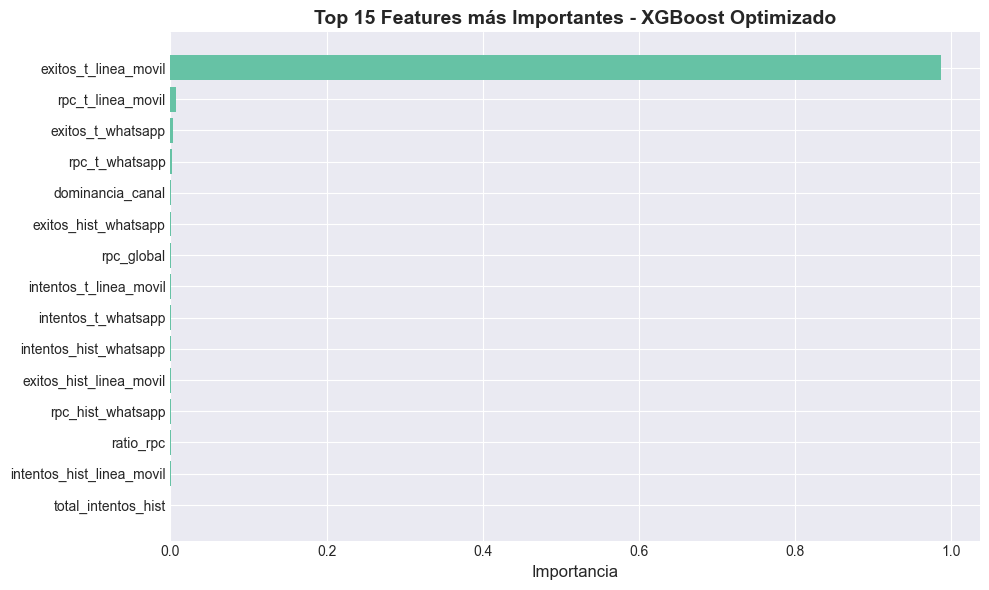

In [180]:
# Feature importance del modelo optimizado
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_tuned.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Features más importantes:\n")
print(feature_importance.head(15))

# Visualización
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Top 15 Features más Importantes - XGBoost Optimizado', 
          fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [182]:
import pickle
import os
from datetime import datetime

# Crear directorio para modelos si no existe
os.makedirs('modelos', exist_ok=True)

# Generar timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Guardar el modelo optimizado
model_filename = f'modelos/xgb_tuned_{timestamp}.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(xgb_tuned, f)

# También guardar la lista de features usadas
features_filename = f'modelos/feature_cols_{timestamp}.pkl'
with open(features_filename, 'wb') as f:
    pickle.dump(feature_cols_final, f)


# Guardar los mejores hiperparámetros
params_filename = f'modelos/best_params_{timestamp}.pkl'
with open(params_filename, 'wb') as f:
    pickle.dump(grid_search.best_params_, f)


## 10. PREDICCIÓN EN DATOS OOT (Out-of-Time)

In [181]:
# Cargar archivo OOT
print("Cargando datos OOT...\n")

df_oot = pd.read_csv("ids_prueba_ba_mejor_canal_contacto_oot.csv")
print(f"✓ Datos OOT cargados: {len(df_oot):,} registros")
print(f"  Columnas: {df_oot.columns.tolist()}")

df_oot.head()

Cargando datos OOT...

✓ Datos OOT cargados: 41,957 registros
  Columnas: ['ID']


,ID
0,-2566145023669016393
1,-2802643317543404810
2,7457484512666334636
3,8320674852027678960
4,-7495693851562851922


In [183]:
MostrarSinLimite(df_modelo.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41487 entries, 0 to 41486
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   id_masked                     41487 non-null  float64       
 1   intentos_hist_linea_movil     41487 non-null  float64       
 2   intentos_hist_whatsapp        41487 non-null  float64       
 3   exitos_hist_linea_movil       41487 non-null  float64       
 4   exitos_hist_whatsapp          41487 non-null  float64       
 5   rpc_hist_linea_movil          41487 non-null  float64       
 6   rpc_hist_whatsapp             41487 non-null  float64       
 7   intentos_t_linea_movil        41487 non-null  float64       
 8   intentos_t_whatsapp           41487 non-null  float64       
 9   exitos_t_linea_movil          41487 non-null  float64       
 10  exitos_t_whatsapp             41487 non-null  float64       
 11  rpc_t_linea_movil           

None

In [184]:
# Preparar datos para predicción

# Crear dataset preparado con id_masked
print(f"   df_modelo registros: {len(df_modelo):,}")
print(f"   df_prep registros: {len(df_prep):,}")

# Obtener id_masked usando los mismos índices de df_prep
df_prep_with_id = df_prep.copy()
df_prep_with_id['id_masked'] = df_modelo.loc[df_prep.index, 'id_masked']

# Merge con datos OOT 
df_oot_pred = df_oot.merge(
    df_prep_with_id, 
    left_on='ID', 
    right_on='id_masked', 
    how='left'
)

print(f"\n Registros OOT después del merge: {len(df_oot_pred):,}")
print(f" Registros con match en datos históricos: {df_oot_pred['id_masked'].notna().sum():,}")
print(f" Registros sin match: {df_oot_pred['id_masked'].isna().sum():,}")

   df_modelo registros: 41,487
   df_prep registros: 41,487

 Registros OOT después del merge: 41,957
 Registros con match en datos históricos: 139
 Registros sin match: 41,818


In [185]:
# Realizar predicciones

# Verificar columnas disponibles
cols_disponibles = [c for c in feature_cols_final if c in df_oot_pred.columns]
cols_faltantes = [c for c in feature_cols_final if c not in df_oot_pred.columns]

print(f" Columnas disponibles: {len(cols_disponibles)}/{len(feature_cols_final)}")
if len(cols_faltantes) > 0:
    print(f" Columnas faltantes: {len(cols_faltantes)}")
    if len(cols_faltantes) <= 10:
        for col in cols_faltantes:
            print(f"   - {col}")
    else:
        for col in cols_faltantes[:10]:
            print(f"   - {col}")
        print(f"   ... y {len(cols_faltantes) - 10} más")

# Separar registros con y sin datos
mask_complete = df_oot_pred[cols_disponibles].notna().all(axis=1)
df_oot_complete = df_oot_pred[mask_complete]
df_oot_incomplete = df_oot_pred[~mask_complete]

print(f"\n Registros completos: {len(df_oot_complete):,}")
print(f" Registros incompletos: {len(df_oot_incomplete):,}")

# Predicciones para registros completos
if len(df_oot_complete) > 0 and len(cols_disponibles) > 0:
    try:
        X_oot = df_oot_complete[cols_disponibles]
        y_proba_oot = xgb_tuned.predict_proba(X_oot)[:, 1]
        
        # Aplicar threshold óptimo encontrado en la optimización
        print(f"\n Usando threshold óptimo: {best_threshold:.3f}")
        y_pred_oot = (y_proba_oot >= best_threshold).astype(int)
        
        df_pred_complete = pd.DataFrame({
            'ID': df_oot_complete['ID'],
            'var_resp': y_pred_oot
        })
        
        print(f" Predicciones realizadas: {len(df_pred_complete):,}")
        print(f"\n Distribución de predicciones OOT:")
        print(f"   Clase 0 (WhatsApp): {(y_pred_oot == 0).sum():,} ({(y_pred_oot == 0).mean()*100:.1f}%)")
        print(f"   Clase 1 (Línea Móvil): {(y_pred_oot == 1).sum():,} ({(y_pred_oot == 1).mean()*100:.1f}%)")
    except Exception as e:
        print(f" Error en predicciones: {e}")
        df_pred_complete = pd.DataFrame(columns=['ID', 'var_resp'])
else:
    df_pred_complete = pd.DataFrame(columns=['ID', 'var_resp'])
    print(f" No se pueden hacer predicciones sin features completas")

# Imputación para registros incompletos
if len(df_oot_incomplete) > 0:
    # Usar la clase mayoritaria del entrenamiento
    valor_default = int(y_train.mode()[0])
    
    df_pred_incomplete = pd.DataFrame({
        'ID': df_oot_incomplete['ID'],
        'var_resp': valor_default
    })
    
    print(f" Imputaciones realizadas: {len(df_pred_incomplete):,} (valor={valor_default})")
else:
    df_pred_incomplete = pd.DataFrame(columns=['ID', 'var_resp'])

 Columnas disponibles: 61/61

 Registros completos: 139
 Registros incompletos: 41,818
 Predicciones realizadas: 139
 Imputaciones realizadas: 41,818 (valor=1)


In [186]:
# Combinar predicciones
df_submission = pd.concat([df_pred_complete, df_pred_incomplete], axis=0)

# Validaciones
print("\nValidaciones finales:")
print(f"  Total registros: {len(df_submission):,}")
print(f"  Registros esperados: {len(df_oot):,}")
print(f"   Match: {len(df_submission) == len(df_oot)}")

assert len(df_submission) == len(df_oot), " Número de registros no coincide"
assert set(df_submission['ID']) == set(df_oot['ID']), " IDs no coinciden"
assert df_submission['var_resp'].isin([0, 1]).all(), " Valores no binarios"

print("\n Todas las validaciones pasadas")

# Distribución de predicciones
print("\nDistribución de predicciones:")
print(df_submission['var_resp'].value_counts())
print("\nProporción:")
print(df_submission['var_resp'].value_counts(normalize=True))


Validaciones finales:
  Total registros: 41,957
  Registros esperados: 41,957
   Match: True

 Todas las validaciones pasadas

Distribución de predicciones:
1    41835
0      122
Name: var_resp, dtype: int64

Proporción:
1    0.997092
0    0.002908
Name: var_resp, dtype: float64


## EXPORTACIÓN DE RESULTADOS

In [ ]:
# Exportar archivo de submission
output_file = "submission_mejor_canal_final2.csv"
df_submission.to_csv(output_file, index=False)

print(f" Archivo exportado: {output_file}")
print(f"  Registros: {len(df_submission):,}")
print(f"  Columnas: {df_submission.columns.tolist()}")

print("\nPrimeras filas del archivo:")
print(df_submission.head(10))

### Exportar con Probabilidades

In [194]:
# Crear archivo con probabilidades
df_submission_probs = pd.DataFrame({
    'ID': df_oot_complete['ID'],
    'var_resp': y_pred_oot,
    'prob': y_proba_oot
})

# Exportar
df_submission_probs.to_csv(' resultado_prueba.csv', index=False)

print("\nÚltimas 5 filas del archivo:")
print(df_submission_probs.tail(5))


Últimas 5 filas del archivo:
                        ID  var_resp      prob
41267  -496378024759208832         0  0.000022
41268 -3610279940314629120         0  0.000008
41768  4621592453278722048         0  0.000011
41807  1381208593430340864         1  0.999999
41944     7961099053814820         0  0.000008
